In [1]:
import sys, os
from pathlib import Path

print("Python executável:", sys.executable)
print("Pasta de trabalho:", os.getcwd())
print()

# Define a raiz do projeto de forma robusta, independente do cwd.
PROJECT_ROOT = Path(r"C:\Users\m\Documents\Tese\Article4")
DATA_DIR     = PROJECT_ROOT / "data"
RESULTS_DIR  = PROJECT_ROOT / "results"
REFS_DIR     = PROJECT_ROOT / "refs"

print("PROJECT_ROOT:", PROJECT_ROOT, "→ existe?", PROJECT_ROOT.exists())
print("DATA_DIR:    ", DATA_DIR,     "→ existe?", DATA_DIR.exists())
print()
print("Ficheiros em DATA_DIR:", [f.name for f in DATA_DIR.iterdir()])

Python executável: C:\Users\m\anaconda3\envs\tese-h2\python.exe
Pasta de trabalho: C:\Users\m\Documents\Tese\Article4\notebooks

PROJECT_ROOT: C:\Users\m\Documents\Tese\Article4 → existe? True
DATA_DIR:     C:\Users\m\Documents\Tese\Article4\data → existe? True

Ficheiros em DATA_DIR: ['oil_majors_h2_data_collection.xlsx']


In [2]:
import numpy as np
import pandas as pd
import pypsa

print(f"NumPy:  {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"PyPSA:  {pypsa.__version__}")

try:
    import highspy
    print("HiGHS:  instalado ✓")
except ImportError:
    print("HiGHS:  EM FALTA — corra numa célula:  !pip install highspy")

NumPy:  1.26.4
Pandas: 2.2.3
PyPSA:  0.35.1
HiGHS:  instalado ✓


In [3]:
# Configuração global do projeto
INVESTMENT_PERIODS = [2025, 2030, 2035, 2040, 2045, 2050]
FIRMS = ["Shell", "TotalEnergies", "BP", "Eni", "Repsol"]
CLIMATE_SCENARIOS = ["STEPS", "APS", "NZE"]
SEED = 42

def annuity_capex(overnight_eur_per_mw: float, wacc: float, lifetime_y: int) -> float:
    """
    Annualised CAPEX (€/MW/y) — usar como `capital_cost` no PyPSA.
    Aplica capital recovery factor (CRF) padrão financeiro.
    """
    if wacc == 0:
        return overnight_eur_per_mw / lifetime_y
    crf = wacc / (1 - (1 + wacc) ** -lifetime_y)
    return overnight_eur_per_mw * crf

# Sanity check: PEM 1500 €/kW (=1.5e6 €/MW), WACC 7%, 20 anos
test = annuity_capex(overnight_eur_per_mw=1_500_000, wacc=0.07, lifetime_y=20)
print(f"Teste: PEM 1500 €/kW → {test:,.0f} €/MW/y → {test/1000:.1f} €/kW/y")
print("(Valor esperado: ~141 €/kW/y — bate certo se aparecer ~141)")

Teste: PEM 1500 €/kW → 141,589 €/MW/y → 141.6 €/kW/y
(Valor esperado: ~141 €/kW/y — bate certo se aparecer ~141)


In [4]:
# Smoke test: 1 refinaria, 168h (uma semana), 1 ano de investimento.
# Objetivo: provar que PyPSA + HiGHS resolvem um problema trivial sem erros.

rng = np.random.default_rng(SEED)
N_HOURS = 168
hours_of_day = np.arange(N_HOURS) % 24

# Perfis sintéticos (substituídos depois pelos dados reais)
solar_cf = np.clip(
    np.sin((hours_of_day - 6) / 12 * np.pi) * 0.7 + rng.normal(0, 0.05, N_HOURS),
    0, 1,
)
solar_cf[(hours_of_day < 6) | (hours_of_day > 19)] = 0
wind_cf = np.clip(rng.beta(2, 4, N_HOURS) * 1.1, 0, 1)

# Procura constante de H2 ≈ 5 t/h numa refinaria média (LHV H2 = 33.33 MWh/t)
H2_DEMAND_T_PER_H = 5.0
h2_demand_mwh = H2_DEMAND_T_PER_H * 33.33

# Construção da rede
n = pypsa.Network()
n.set_snapshots(pd.RangeIndex(N_HOURS))

n.add("Carrier", "AC")
n.add("Carrier", "H2")

n.add("Bus", "power", carrier="AC")
n.add("Bus", "h2",    carrier="H2")

n.add("Load", "refinery_h2", bus="h2", p_set=h2_demand_mwh)

# Renováveis extendable — anuidade dividida por 52 para escalar 1 semana
n.add("Generator", "solar", bus="power",
      p_nom_extendable=True, p_max_pu=solar_cf,
      capital_cost=annuity_capex(800_000, 0.07, 25) / 52)
n.add("Generator", "wind",  bus="power",
      p_nom_extendable=True, p_max_pu=wind_cf,
      capital_cost=annuity_capex(1_300_000, 0.07, 25) / 52)

# Grid: capacidade fixa elevada, custo marginal = preço de mercado
n.add("Generator", "grid", bus="power", p_nom=1e6, marginal_cost=80.0)

# Eletrolisador PEM
n.add("Link", "pem", bus0="power", bus1="h2",
      p_nom_extendable=True, efficiency=0.65, p_min_pu=0.10,
      capital_cost=annuity_capex(1_500_000, 0.07, 20) / 52)

print(f"Rede construída: {len(n.buses)} buses, {len(n.generators)} generators, {len(n.links)} links")

# Resolver
import time
t0 = time.time()
status = n.optimize(solver_name="highs")
print(f"\nSolver: {status}   |   tempo: {time.time()-t0:.1f}s\n")

# Resultados
print(f"Capacidades ótimas:")
print(f"  Solar : {n.generators.at['solar','p_nom_opt']:>7.1f} MW")
print(f"  Wind  : {n.generators.at['wind', 'p_nom_opt']:>7.1f} MW")
print(f"  PEM   : {n.links.at['pem',      'p_nom_opt']:>7.1f} MW")

grid_share = n.generators_t.p['grid'].sum() / n.generators_t.p.sum().sum()
print(f"\nFração da eletricidade vinda da rede: {grid_share:.1%}")

# LCOH muito grosseiro: custo total / kg H2 produzido
total_cost = n.objective
h2_kg = n.loads_t.p['refinery_h2'].sum() / 33.33 * 1000
print(f"LCOH (estimativa grosseira semanal): {total_cost / h2_kg:.2f} €/kg")

Rede construída: 2 buses, 3 generators, 1 links


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.12s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 675 primals, 1683 duals
Objective: 2.86e+06
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper were not assigned to the network.



Solver: ('ok', 'optimal')   |   tempo: 1.2s

Capacidades ótimas:
  Solar :   138.0 MW
  Wind  :   552.0 MW
  PEM   :   256.4 MW

Fração da eletricidade vinda da rede: 23.1%
LCOH (estimativa grosseira semanal): 3.40 €/kg


In [5]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [6]:
print("p_max_pu dim_names:", n.generators_t.p_max_pu.columns.names if hasattr(n.generators_t.p_max_pu.columns, 'names') else 'no MI')
print("Snapshots type :", type(n.snapshots))

p_max_pu dim_names: ['Generator']
Snapshots type : <class 'pandas.core.indexes.range.RangeIndex'>


In [7]:
# Horizonte temporal — usando datetime, padrão oficial PyPSA
N_HOURS_PER_PERIOD = 24
YEARS_PER_PERIOD   = 5
DISCOUNT_RATE      = 0.05

# Curvas de aprendizagem (PLACEHOLDER — ligar depois ao Excel)
CAPEX_TRAJ = pd.DataFrame({
    "solar_capex": [ 800,  700,  600,  550,  500,  480],
    "wind_capex":  [1300, 1200, 1100, 1050, 1000,  980],
    "pem_capex":   [1500, 1300, 1100,  950,  850,  800],
    "pem_eff":     [0.65, 0.67, 0.69, 0.70, 0.71, 0.72],
    "wacc":        [0.07] * 6,
}, index=INVESTMENT_PERIODS)
CAPEX_TRAJ.index.name = "build_year"

# === SNAPSHOTS: padrão oficial PyPSA com datetime + MultiIndex.from_arrays ===
datetime_index = pd.DatetimeIndex([])
for year in INVESTMENT_PERIODS:
    period = pd.date_range(
        start=f"{year}-01-01 00:00",
        freq="h",
        periods=N_HOURS_PER_PERIOD,
    )
    datetime_index = datetime_index.append(period)

snapshots = pd.MultiIndex.from_arrays([datetime_index.year, datetime_index])

print("Curvas de aprendizagem:")
print(CAPEX_TRAJ)
print(f"\nTotal snapshots: {len(snapshots)}")
print(f"Primeiros 3 snapshots: {snapshots[:3].tolist()}")
print(f"Últimos 3 snapshots:   {snapshots[-3:].tolist()}")

Curvas de aprendizagem:
            solar_capex  wind_capex  pem_capex  pem_eff  wacc
build_year                                                   
2025                800        1300       1500     0.65  0.07
2030                700        1200       1300     0.67  0.07
2035                600        1100       1100     0.69  0.07
2040                550        1050        950     0.70  0.07
2045                500        1000        850     0.71  0.07
2050                480         980        800     0.72  0.07

Total snapshots: 144
Primeiros 3 snapshots: [(2025, Timestamp('2025-01-01 00:00:00')), (2025, Timestamp('2025-01-01 01:00:00')), (2025, Timestamp('2025-01-01 02:00:00'))]
Últimos 3 snapshots:   [(2050, Timestamp('2050-01-01 21:00:00')), (2050, Timestamp('2050-01-01 22:00:00')), (2050, Timestamp('2050-01-01 23:00:00'))]


In [8]:
import time

# === Construir a rede ===
n = pypsa.Network()
n.set_snapshots(snapshots)
n.set_investment_periods(INVESTMENT_PERIODS)

# Pesos de período (anos representados + fator de desconto)
T0 = INVESTMENT_PERIODS[0]
n.investment_period_weightings["years"]     = YEARS_PER_PERIOD
n.investment_period_weightings["objective"] = [
    (1 + DISCOUNT_RATE) ** -(y - T0) for y in INVESTMENT_PERIODS
]

# Pesos de snapshot — atribuir por COLUNAS individualmente (mais robusto)
sw_value = YEARS_PER_PERIOD * 8760 / N_HOURS_PER_PERIOD
n.snapshot_weightings["objective"]  = sw_value
n.snapshot_weightings["generators"] = sw_value
n.snapshot_weightings["stores"]     = sw_value

# === Perfis usando n.snapshots DIRETAMENTE (sem manipular nomes) ===
rng = np.random.default_rng(SEED)
hd  = np.arange(N_HOURS_PER_PERIOD) % 24
solar_24h = np.clip(np.sin((hd - 6) / 12 * np.pi) * 0.7 + rng.normal(0, 0.05, N_HOURS_PER_PERIOD), 0, 1)
solar_24h[(hd < 6) | (hd > 19)] = 0
wind_24h  = np.clip(rng.beta(2, 4, N_HOURS_PER_PERIOD) * 1.1, 0, 1)

solar_full = pd.Series(np.tile(solar_24h, len(INVESTMENT_PERIODS)), index=n.snapshots)
wind_full  = pd.Series(np.tile(wind_24h,  len(INVESTMENT_PERIODS)), index=n.snapshots)

h2_demand_per_period = {2025: 5, 2030: 5, 2035: 6, 2040: 7, 2045: 8, 2050: 10}
h2_demand_full = pd.Series(
    [h2_demand_per_period[y] * 33.33 for y, _ in n.snapshots],
    index=n.snapshots,
)

# Carriers e buses
for c in ["AC", "H2", "solar", "onwind", "pem", "grid"]:
    n.add("Carrier", c)
n.add("Bus", "power", carrier="AC")
n.add("Bus", "h2",    carrier="H2")

# Demanda
n.add("Load", "refinery_h2", bus="h2", p_set=h2_demand_full)

# Grid de fallback
n.add("Generator", "grid", bus="power", p_nom=1e6, marginal_cost=80.0, carrier="grid")

# Vintages
for by in INVESTMENT_PERIODS:
    row = CAPEX_TRAJ.loc[by]
    n.add("Generator", f"solar_{by}",
          bus="power", carrier="solar",
          p_nom_extendable=True, p_max_pu=solar_full,
          capital_cost=annuity_capex(row["solar_capex"] * 1000, row["wacc"], 25),
          build_year=by, lifetime=25)
    n.add("Generator", f"wind_{by}",
          bus="power", carrier="onwind",
          p_nom_extendable=True, p_max_pu=wind_full,
          capital_cost=annuity_capex(row["wind_capex"] * 1000, row["wacc"], 25),
          build_year=by, lifetime=25)
    n.add("Link", f"pem_{by}",
          bus0="power", bus1="h2", carrier="pem",
          p_nom_extendable=True, efficiency=row["pem_eff"], p_min_pu=0.10,
          capital_cost=annuity_capex(row["pem_capex"] * 1000, row["wacc"], 20),
          build_year=by, lifetime=20)

print(f"Rede: {len(n.buses)} buses, {len(n.generators)} generators, {len(n.links)} links")
print(f"Investment periods: {list(n.investment_periods)}")
print(f"Total snapshots: {len(n.snapshots)}")

t0 = time.time()
status = n.optimize(solver_name="highs", multi_investment_periods=True)
print(f"\nSolver: {status}  |  tempo: {time.time()-t0:.1f}s")

Rede: 2 buses, 13 generators, 6 links
Investment periods: [2025, 2030, 2035, 2040, 2045, 2050]
Total snapshots: 144


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.13s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 1554 primals, 3378 duals
Objective: 9.27e+08
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper were not assigned to the network.



Solver: ('ok', 'optimal')  |  tempo: 1.9s


Capacity ADDED in each investment period (MW):
            Solar PV  Onshore Wind  PEM electrolyser
Build year                                          
2025           364.5        1183.9             256.4
2030            -0.0          -0.0              -0.0
2035            68.7         223.0              48.3
2040            67.7         219.9              47.6
2045            12.5         253.9             281.7
2050           490.4        1645.0              92.6

Operational capacity per period, after decommissioning (MW):
      Solar PV  Onshore Wind  PEM electrolyser
2025     364.5        1183.9             256.4
2030     364.5        1183.9             256.4
2035     433.2        1406.9             304.7
2040     500.9        1626.8             352.3
2045     513.3        1880.7             377.6
2050     639.2        2341.9             470.2

Total objective (NPV, €): 926,675,213


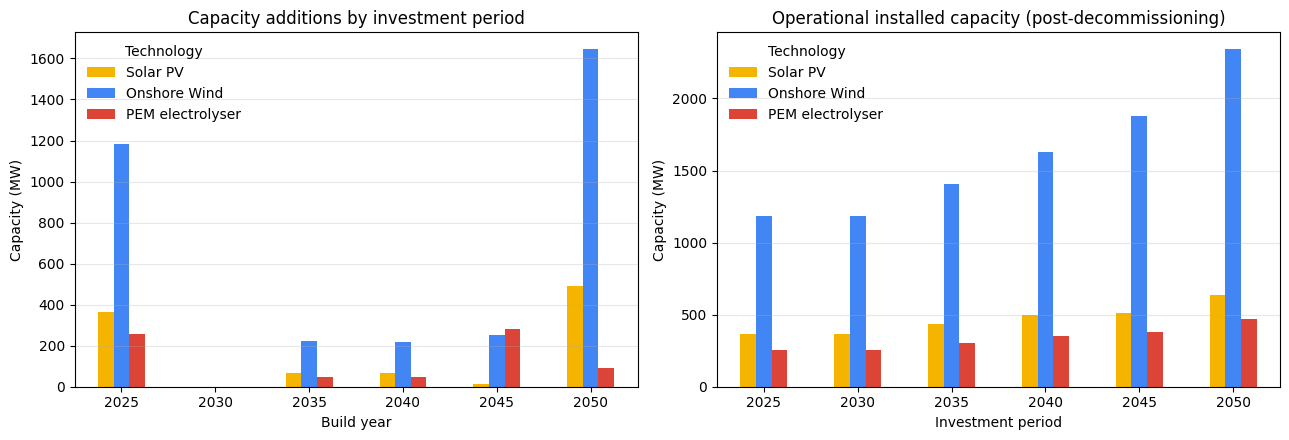

In [10]:
import matplotlib.pyplot as plt

# Added capacity per investment period (decision variable)
added = pd.DataFrame({
    "Solar PV":      [n.generators.at[f"solar_{by}", "p_nom_opt"] for by in INVESTMENT_PERIODS],
    "Onshore Wind":  [n.generators.at[f"wind_{by}",  "p_nom_opt"] for by in INVESTMENT_PERIODS],
    "PEM electrolyser": [n.links.at[f"pem_{by}",     "p_nom_opt"] for by in INVESTMENT_PERIODS],
}, index=INVESTMENT_PERIODS)
added.index.name = "Build year"

# Operational capacity per period (cumulative, accounting for lifetime)
lifetimes = {"Solar PV": 25, "Onshore Wind": 25, "PEM electrolyser": 20}
operational = pd.DataFrame(0.0, index=INVESTMENT_PERIODS, columns=added.columns)
for tech, lt in lifetimes.items():
    for by in INVESTMENT_PERIODS:
        for y in INVESTMENT_PERIODS:
            if by <= y < by + lt:
                operational.at[y, tech] += added.at[by, tech]

print("Capacity ADDED in each investment period (MW):")
print(added.round(1))
print("\nOperational capacity per period, after decommissioning (MW):")
print(operational.round(1))
print(f"\nTotal objective (NPV, €): {n.objective:,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colors = ["#F4B400", "#4285F4", "#DB4437"]   # solar yellow, wind blue, electrolyser red

added.plot(kind="bar", ax=axes[0], color=colors)
axes[0].set_title("Capacity additions by investment period")
axes[0].set_ylabel("Capacity (MW)")
axes[0].set_xlabel("Build year")
axes[0].legend(title="Technology", frameon=False)
axes[0].grid(axis="y", alpha=0.3)
axes[0].tick_params(axis="x", rotation=0)

operational.plot(kind="bar", ax=axes[1], color=colors)
axes[1].set_title("Operational installed capacity (post-decommissioning)")
axes[1].set_ylabel("Capacity (MW)")
axes[1].set_xlabel("Investment period")
axes[1].legend(title="Technology", frameon=False)
axes[1].grid(axis="y", alpha=0.3)
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [11]:
# Excel reader setup
EXCEL_PATH = DATA_DIR / "oil_majors_h2_data_collection.xlsx"
print(f"Reading from: {EXCEL_PATH}")
print(f"File exists:  {EXCEL_PATH.exists()}")

# List all sheets in the workbook
xl = pd.ExcelFile(EXCEL_PATH)
print(f"\nSheets found ({len(xl.sheet_names)}):")
for s in xl.sheet_names:
    print(f"  - {s}")

Reading from: C:\Users\m\Documents\Tese\Article4\data\oil_majors_h2_data_collection.xlsx
File exists:  True

Sheets found (12):
  - 00_README
  - 01_Company_Overview
  - 02_Refinery_Inventory
  - 03_Current_H2_Demand
  - 04_GreenH2_Projects
  - 05_Renewable_Portfolio
  - 06_PPAs
  - 07_Decarb_Targets
  - 08_Financial_Disclosures
  - 09_Cost_Params_MC
  - 10_Climate_Scenarios
  - 11_Sources


In [12]:
def read_sheet(sheet_name: str, header_row: int = 0) -> pd.DataFrame:
    """
    Read a sheet from the data workbook, defensively.
    Returns DataFrame even if all data cells are empty (lets us inspect structure).
    """
    df = pd.read_excel(EXCEL_PATH, sheet_name=sheet_name, header=header_row)
    # Drop fully empty rows (artifact of pre-allocated rows in the template)
    df = df.dropna(how="all").reset_index(drop=True)
    return df


def is_empty(value) -> bool:
    """True if value is NaN, None, empty string, or whitespace-only."""
    if pd.isna(value):
        return True
    if isinstance(value, str) and value.strip() == "":
        return True
    return False


def report_completeness(df: pd.DataFrame, sheet_name: str,
                        key_columns: list[str]) -> None:
    """Print a quick fill-rate report for the columns that matter for the model."""
    print(f"\n=== {sheet_name} ===")
    print(f"Rows (after dropping empty): {len(df)}")
    if len(df) == 0:
        print("  (sheet is empty)")
        return
    print("Fill rate of key columns:")
    for col in key_columns:
        if col not in df.columns:
            print(f"  {col:<35} NOT FOUND in columns")
            continue
        filled = df[col].apply(lambda v: not is_empty(v)).sum()
        pct = 100 * filled / len(df)
        bar = "█" * int(pct / 5) + "·" * (20 - int(pct / 5))
        print(f"  {col:<35} {filled:>3}/{len(df):<3}  {pct:>5.0f}%  {bar}")


print("Helper functions defined.")

Helper functions defined.


In [15]:
# Run a completeness audit on the sheets that feed the model directly.
# Some sheets have decorative header rows above the column names — specify header_row.

sheets_to_audit = {
    "01_Company_Overview": (0, [
        "Company",
        "Total CAPEX (€bn)",
        "Low-carbon CAPEX (€bn)",
        "EU refining capacity (kbpd)",
        "Announced green H₂ by 2030 (kt/y)",
        "Net-zero target year",
        "Source_ID",
    ]),
    "02_Refinery_Inventory": (0, [
        "Company", "Refinery", "Country",
        "Nameplate capacity (kbpd)",
        "Status (Operating / Idled / Converting / Closed)",
        "Source_ID",
    ]),
    "03_Current_H2_Demand": (0, [
        "Company", "Refinery",
        "Captive SMR H₂ (kt/y)",
        "Total H₂ demand (kt/y)",
        "Source_ID",
    ]),
    "04_GreenH2_Projects": (0, [
        "Company", "Project name",
        "Electrolyser capacity (MWel)",
        "CAPEX (€m)", "COD (year)",
        "Status (Announced / FEED / FID / UC / Operational / Cancelled)",
        "Source_ID",
    ]),
    "07_Decarb_Targets": (0, [
        "Company",
        "Scope 1 baseline (Mt CO₂e)",
        "Net-zero year (Scope 1+2)",
        "Internal carbon price (€/t CO₂)",
        "Source_ID",
    ]),
    "09_Cost_Params_MC": (3, [   # decorative title rows above headers → header on row 4
        "Technology / Parameter",
        "Min", "Mode", "Max", "Source_ID",
    ]),
    "10_Climate_Scenarios": (0, [
        "Scenario", "Variable", "Source_ID",
    ]),
    "11_Sources": (0, [
        "Source_ID", "Title", "URL / DOI",
    ]),
}

for sheet, (header_row, key_cols) in sheets_to_audit.items():
    df = read_sheet(sheet, header_row=header_row)
    report_completeness(df, sheet, key_cols)


=== 01_Company_Overview ===
Rows (after dropping empty): 5
Fill rate of key columns:
  Company                               5/5      100%  ████████████████████
  Total CAPEX (€bn)                     0/5        0%  ····················
  Low-carbon CAPEX (€bn)                0/5        0%  ····················
  EU refining capacity (kbpd)           0/5        0%  ····················
  Announced green H₂ by 2030 (kt/y)     0/5        0%  ····················
  Net-zero target year                  0/5        0%  ····················
  Source_ID                             0/5        0%  ····················

=== 02_Refinery_Inventory ===
Rows (after dropping empty): 23
Fill rate of key columns:
  Company                              23/23     100%  ████████████████████
  Refinery                             22/23      96%  ███████████████████·
  Country                              22/23      96%  ███████████████████·
  Nameplate capacity (kbpd)             0/23       0%  ··········

In [16]:
def load_cost_params(scenario_mode: str = "mode") -> pd.DataFrame:
    """
    Load technology cost parameters from sheet 09 for use in the PyPSA model.
    
    Parameters
    ----------
    scenario_mode : str
        Which point estimate to use: 'min', 'mode', 'max', or 'mean' (of min,mode,max).
        For Monte Carlo we'll sample from the triangular dist; for deterministic
        baseline runs, use 'mode'.
    
    Returns
    -------
    DataFrame indexed by parameter name, with one 'value' column.
    """
    df = read_sheet("09_Cost_Params_MC", header_row=3)   # headers are on row 4 (0-indexed 3)
    # Drop section-divider rows (those starting with "—")
    df = df[~df["Technology / Parameter"].astype(str).str.startswith("—")]
    df = df.dropna(subset=["Technology / Parameter"]).reset_index(drop=True)
    
    if scenario_mode == "mean":
        df["value"] = df[["Min", "Mode", "Max"]].mean(axis=1)
    else:
        df["value"] = df[scenario_mode.capitalize()]
    
    result = df.set_index("Technology / Parameter")[["Unit", "value", "Source_ID"]]
    return result


# Test it (will return mostly NaNs since the sheet is empty, but should not crash)
try:
    costs = load_cost_params(scenario_mode="mode")
    print(f"Loaded {len(costs)} cost parameters from sheet 09_Cost_Params_MC")
    print(f"\nFirst 5 rows:")
    print(costs.head())
    print(f"\nFilled parameters (non-NaN 'value'): {costs['value'].notna().sum()} / {len(costs)}")
except Exception as e:
    print(f"Loader failed with: {type(e).__name__}: {e}")
    print("→ Likely cause: column names in sheet 09 don't match expectations.")
    print("→ Run: pd.read_excel(EXCEL_PATH, '09_Cost_Params_MC', header=3).columns.tolist()")

Loaded 28 cost parameters from sheet 09_Cost_Params_MC

First 5 rows:
                                      Unit  value  Source_ID
Technology / Parameter                                      
PEM CAPEX                             €/kW    NaN        NaN
PEM OPEX (% CAPEX/y)                   %/y    NaN        NaN
PEM efficiency (LHV)                     %    NaN        NaN
PEM stack lifetime                       h    NaN        NaN
PEM stack replacement cost (% CAPEX)     %    NaN        NaN

Filled parameters (non-NaN 'value'): 0 / 28


In [17]:
def load_refineries(only_operating: bool = False) -> pd.DataFrame:
    """
    Load refinery inventory from sheet 02.
    
    Parameters
    ----------
    only_operating : bool
        If True, drop refineries whose Status doesn't contain 'Operating'.
        For early development this stays False so we see the full template.
    
    Returns
    -------
    DataFrame indexed by Refinery, with columns for the model:
        company, country, location, capacity_kbpd, status, source_id
    """
    df = read_sheet("02_Refinery_Inventory", header_row=0)
    
    # Standardise column names to snake_case for code-friendliness
    rename_map = {
        "Company": "company",
        "Refinery": "refinery",
        "Country": "country",
        "Location (city)": "location",
        "Ownership %": "ownership_pct",
        "Nameplate capacity (kbpd)": "capacity_kbpd",
        "Nelson complexity": "nelson",
        "Status (Operating / Idled / Converting / Closed)": "status",
        "Conversion plan": "conversion_plan",
        "Source_ID": "source_id",
    }
    df = df.rename(columns=rename_map)
    keep = [c for c in rename_map.values() if c in df.columns]
    df = df[keep].copy()
    
    # Drop the trailing instructional note row (it has text in column 1 only)
    df = df[df["company"].notna() & df["refinery"].notna()].reset_index(drop=True)
    
    if only_operating and "status" in df.columns:
        df = df[df["status"].astype(str).str.contains("Operating", na=False)].reset_index(drop=True)
    
    return df


# Test
refs = load_refineries()
print(f"Loaded {len(refs)} refineries")
print(f"\nBreakdown by company:")
print(refs["company"].value_counts())
print(f"\nFirst 5 rows:")
print(refs.head().to_string(index=False))

# Critical metric for the model
filled_capacity = refs["capacity_kbpd"].notna().sum() if "capacity_kbpd" in refs.columns else 0
print(f"\nRefineries with capacity_kbpd filled: {filled_capacity}/{len(refs)}")

Loaded 22 refineries

Breakdown by company:
company
TotalEnergies SE    7
Eni S.p.A.          5
Repsol S.A.         5
BP plc              3
Shell plc           2
Name: count, dtype: int64

First 5 rows:
         company                       refinery     country  location  ownership_pct  capacity_kbpd  nelson  status  conversion_plan  source_id
       Shell plc                         Pernis Netherlands Rotterdam            NaN            NaN     NaN     NaN              NaN        NaN
       Shell plc Rheinland (Wesseling + Godorf)     Germany   Cologne            NaN            NaN     NaN     NaN              NaN        NaN
TotalEnergies SE                         Donges      France    Donges            NaN            NaN     NaN     NaN              NaN        NaN
TotalEnergies SE                    Gonfreville      France  Le Havre            NaN            NaN     NaN     NaN              NaN        NaN
TotalEnergies SE                         Feyzin      France      Lyon        

In [18]:
def load_h2_projects(min_status: str = "Announced") -> pd.DataFrame:
    """
    Load green H2 project pipeline from sheet 04.

    Parameters
    ----------
    min_status : str
        Lowest project maturity to include. Order: Announced < FEED < FID < UC < Operational.
        For Article 4 modelling we typically include FID+ as 'committed';
        Announced/FEED as 'optional pipeline'.

    Returns
    -------
    DataFrame with one row per project, columns:
        company, project, country, site, capacity_mw, technology,
        h2_output_kt_y, capex_eur_m, cod_year, status, source_id
    """
    df = read_sheet("04_GreenH2_Projects", header_row=0)
    
    rename_map = {
        "Company": "company",
        "Project name": "project",
        "Country": "country",
        "Site / refinery linked": "site",
        "Partners": "partners",
        "Electrolyser capacity (MWel)": "capacity_mw",
        "Technology (PEM / AEL / SOEC)": "technology",
        "Expected H₂ output (kt/y)": "h2_output_kt_y",
        "CAPEX (€m)": "capex_eur_m",
        "Public funding (€m)": "public_funding_eur_m",
        "Funding scheme": "funding_scheme",
        "Year announced": "year_announced",
        "FID year": "fid_year",
        "COD (year)": "cod_year",
        "Status (Announced / FEED / FID / UC / Operational / Cancelled)": "status",
        "Offtake / end-use": "offtake",
        "Source_ID": "source_id",
    }
    df = df.rename(columns=rename_map)
    keep = [c for c in rename_map.values() if c in df.columns]
    df = df[keep].copy()
    
    # Drop fully empty pre-allocated rows
    df = df[df["project"].notna() | df["company"].notna()].reset_index(drop=True)
    
    # Filter by minimum status (only if status column has data)
    status_order = ["Announced", "FEED", "FID", "UC", "Operational"]
    if min_status in status_order and "status" in df.columns:
        valid = status_order[status_order.index(min_status):]
        df_with_status = df[df["status"].astype(str).isin(valid)]
        # Keep rows with NaN status too during development (don't hide template rows)
        df = pd.concat([df_with_status, df[df["status"].isna()]]).reset_index(drop=True)
    
    return df


# Test
projects = load_h2_projects(min_status="Announced")
print(f"Loaded {len(projects)} projects")
if len(projects) > 0:
    print(f"\nBy company:")
    print(projects["company"].value_counts())
    filled_capex = projects["capex_eur_m"].notna().sum()
    filled_cod = projects["cod_year"].notna().sum()
    print(f"\nWith CAPEX disclosed:   {filled_capex}/{len(projects)}")
    print(f"With COD disclosed:     {filled_cod}/{len(projects)}")

Loaded 1 projects

By company:
company
Recommended sources: IEA Hydrogen Projects Database (https://www.iea.org/data-and-statistics/data-product/hydrogen-projects-database), Hydrogen Europe Clean Hydrogen Monitor, company press releases. Cross-check CAPEX against Clean Hydrogen Partnership / IPCEI Hy2Tech & Hy2Use funding decisions.    1
Name: count, dtype: int64

With CAPEX disclosed:   0/1
With COD disclosed:     0/1


In [20]:
def load_climate_scenarios() -> pd.DataFrame:
    """
    Load STEPS/APS/NZE trajectories from sheet 10.
    """
    df = read_sheet("10_Climate_Scenarios", header_row=0)
    
    df = df.rename(columns={
        "Scenario": "scenario",
        "Variable": "variable",
        "Source_ID": "source_id",
        "Notes": "notes",
    })
    
    # Detect year columns. Keep ORIGINAL labels (string or int — whatever pandas read).
    year_cols_original = []
    year_cols_int = []
    for c in df.columns:
        try:
            y = int(c)
            if 2020 <= y <= 2060:
                year_cols_original.append(c)
                year_cols_int.append(y)
        except (ValueError, TypeError):
            continue
    
    if not year_cols_original:
        print("Warning: no year columns detected in sheet 10. Check header_row.")
        return pd.DataFrame()
    
    id_vars = [c for c in ["scenario", "variable", "source_id"] if c in df.columns]
    df_long = df.melt(
        id_vars=id_vars,
        value_vars=year_cols_original,   # use original labels, not converted ints
        var_name="year",
        value_name="value",
    )
    df_long["year"] = pd.to_numeric(df_long["year"], errors="coerce").astype("Int64")
    df_long = df_long.dropna(subset=["scenario", "variable"]).reset_index(drop=True)
    return df_long


def get_scenario_trajectory(scenario: str, variable_contains: str) -> pd.Series:
    """Return a single trajectory as Series indexed by year."""
    df = load_climate_scenarios()
    sel = df[(df["scenario"] == scenario)
             & (df["variable"].astype(str).str.contains(variable_contains, case=False, regex=False))]
    if len(sel) == 0:
        print(f"  No match for scenario='{scenario}', variable contains '{variable_contains}'")
        return pd.Series(dtype=float)
    return sel.set_index("year")["value"].sort_index()


# Test
scenarios_df = load_climate_scenarios()
print(f"Loaded {len(scenarios_df)} (scenario, variable, year) cells")
if len(scenarios_df) > 0:
    print(f"\nScenarios present: {sorted(scenarios_df['scenario'].unique())}")
    print(f"Variables present: {scenarios_df['variable'].nunique()}")
    filled = scenarios_df["value"].notna().sum()
    print(f"Cells with values filled: {filled}/{len(scenarios_df)} ({100*filled/len(scenarios_df):.0f}%)")
    
    print("\n--- Example: NZE carbon price trajectory ---")
    traj = get_scenario_trajectory("NZE", "Carbon price")
    print(traj)

Loaded 126 (scenario, variable, year) cells

Scenarios present: ['APS', 'NZE', 'STEPS']
Variables present: 7
Cells with values filled: 0/126 (0%)

--- Example: NZE carbon price trajectory ---
year
2025   NaN
2030   NaN
2035   NaN
2040   NaN
2045   NaN
2050   NaN
Name: value, dtype: float64


In [21]:
# Quick dashboard: how much real data is now reachable from the model?
print("=" * 60)
print("DATA AVAILABILITY DASHBOARD")
print("=" * 60)

costs = load_cost_params(scenario_mode="mode")
refs = load_refineries()
projects = load_h2_projects()
scenarios_df = load_climate_scenarios()

def fill_rate(s):
    if len(s) == 0:
        return "0/0   (empty)"
    n = s.notna().sum()
    return f"{n}/{len(s)} ({100*n/len(s):.0f}%)"

print(f"\nCost parameters (sheet 09):")
print(f"  rows in sheet:      {len(costs)}")
print(f"  with value filled:  {fill_rate(costs['value'])}")

print(f"\nRefineries (sheet 02):")
print(f"  rows in sheet:      {len(refs)}")
print(f"  with capacity_kbpd: {fill_rate(refs['capacity_kbpd']) if 'capacity_kbpd' in refs.columns else 'col missing'}")
print(f"  with status:        {fill_rate(refs['status']) if 'status' in refs.columns else 'col missing'}")

print(f"\nH2 projects (sheet 04):")
print(f"  rows in sheet:      {len(projects)}")
if len(projects) > 0:
    print(f"  with capacity_mw:   {fill_rate(projects['capacity_mw'])}")
    print(f"  with cod_year:      {fill_rate(projects['cod_year'])}")
    print(f"  with capex_eur_m:   {fill_rate(projects['capex_eur_m'])}")

print(f"\nClimate scenarios (sheet 10):")
print(f"  total cells:        {len(scenarios_df)}")
if len(scenarios_df) > 0:
    print(f"  with value filled:  {fill_rate(scenarios_df['value'])}")

print("\n" + "=" * 60)
print("Bridge Excel → model is in place. As you fill the workbook,")
print("re-run this cell to see progress. No code changes needed.")
print("=" * 60)

DATA AVAILABILITY DASHBOARD

Cost parameters (sheet 09):
  rows in sheet:      28
  with value filled:  0/28 (0%)

Refineries (sheet 02):
  rows in sheet:      22
  with capacity_kbpd: 0/22 (0%)
  with status:        0/22 (0%)

H2 projects (sheet 04):
  rows in sheet:      1
  with capacity_mw:   0/1 (0%)
  with cod_year:      0/1 (0%)
  with capex_eur_m:   0/1 (0%)

Climate scenarios (sheet 10):
  total cells:        126
  with value filled:  0/126 (0%)

Bridge Excel → model is in place. As you fill the workbook,
re-run this cell to see progress. No code changes needed.


In [22]:
def load_h2_projects(min_status: str = "Announced") -> pd.DataFrame:
    """Load green H2 project pipeline from sheet 04."""
    df = read_sheet("04_GreenH2_Projects", header_row=0)
    
    rename_map = {
        "Company": "company", "Project name": "project", "Country": "country",
        "Site / refinery linked": "site", "Partners": "partners",
        "Electrolyser capacity (MWel)": "capacity_mw",
        "Technology (PEM / AEL / SOEC)": "technology",
        "Expected H₂ output (kt/y)": "h2_output_kt_y",
        "CAPEX (€m)": "capex_eur_m", "Public funding (€m)": "public_funding_eur_m",
        "Funding scheme": "funding_scheme", "Year announced": "year_announced",
        "FID year": "fid_year", "COD (year)": "cod_year",
        "Status (Announced / FEED / FID / UC / Operational / Cancelled)": "status",
        "Offtake / end-use": "offtake", "Source_ID": "source_id",
    }
    df = df.rename(columns=rename_map)
    keep = [c for c in rename_map.values() if c in df.columns]
    df = df[keep].copy()
    
    # Real project rows must have BOTH a company name AND a project name.
    # This filters out the trailing instructional note ("Recommended sources: ...").
    df = df[df["company"].notna() & df["project"].notna()].reset_index(drop=True)
    
    # Real companies are one of FIRMS — defensive filter against text accidentally
    # caught in the company column.
    df = df[df["company"].isin(FIRMS + [f"{f} plc" for f in FIRMS] + 
                                ["Shell plc", "TotalEnergies SE", "BP plc",
                                 "Eni S.p.A.", "Repsol S.A."])].reset_index(drop=True)
    
    return df


projects = load_h2_projects()
print(f"Loaded {len(projects)} projects (after filtering)")

Loaded 0 projects (after filtering)


In [23]:
# Capture the current environment into requirements.txt
import subprocess, sys

result = subprocess.run(
    [sys.executable, "-m", "pip", "freeze"],
    capture_output=True, text=True, check=True,
)
all_packages = result.stdout

# Filter to just the packages we actually care about (avoid 200+ noise lines)
KEY_PACKAGES = [
    "pypsa", "linopy", "highspy",
    "numpy", "pandas", "scipy", "xarray",
    "matplotlib", "seaborn",
    "openpyxl",
    "tsam", "scikit-learn",
    "jupyterlab", "ipykernel",
]

requirements_path = PROJECT_ROOT / "requirements.txt"
with open(requirements_path, "w") as f:
    f.write("# Article 4 — frozen environment\n")
    f.write("# Generated automatically. To reproduce:\n")
    f.write("#   conda create -n tese-h2 python=3.11 -y\n")
    f.write("#   conda activate tese-h2\n")
    f.write("#   pip install -r requirements.txt\n\n")
    
    for line in all_packages.splitlines():
        pkg_name = line.split("==")[0].split(" ")[0].lower()
        if pkg_name in KEY_PACKAGES:
            f.write(line + "\n")

print(f"Written: {requirements_path}")
print()
print("Content:")
print(open(requirements_path).read())

Written: C:\Users\m\Documents\Tese\Article4\requirements.txt

Content:
# Article 4 — frozen environment
# Generated automatically. To reproduce:
#   conda create -n tese-h2 python=3.11 -y
#   conda activate tese-h2
#   pip install -r requirements.txt

highspy==1.14.0
ipykernel==7.2.0
jupyterlab==4.5.7
linopy==0.5.8
matplotlib==3.10.9
numpy==1.26.4
openpyxl==3.1.5
pandas==2.2.3
pypsa==0.35.1
scikit-learn==1.8.0
scipy==1.17.1
seaborn==0.13.2
tsam==3.4.0
xarray==2024.11.0



In [24]:
environment_yml = """\
# Article 4 — Conda environment specification
# Reproduce with:  conda env create -f environment.yml

name: tese-h2
channels:
  - conda-forge
  - defaults
dependencies:
  - python=3.11
  - pip
  - pip:
    - -r requirements.txt
"""

env_path = PROJECT_ROOT / "environment.yml"
with open(env_path, "w") as f:
    f.write(environment_yml)

print(f"Written: {env_path}")
print()
print(open(env_path).read())

Written: C:\Users\m\Documents\Tese\Article4\environment.yml

# Article 4 — Conda environment specification
# Reproduce with:  conda env create -f environment.yml

name: tese-h2
channels:
  - conda-forge
  - defaults
dependencies:
  - python=3.11
  - pip
  - pip:
    - -r requirements.txt



In [26]:
readme_lines = [
    "# Article 4 - Paris-aligned Green Hydrogen Pathways for European Oil Majors",
    "",
    "PhD thesis (Ernesto Relogio, Universidade de Aveiro).",
    "Multi-firm energy system optimisation framework with stochastic LCOH and",
    "real options analysis under climate budget constraints.",
    "",
    "## Folder structure",
    "",
    "    Article4/",
    "    |-- notebooks/              Jupyter notebooks, numbered by stage",
    "    |   `-- 01_smoke_test.ipynb",
    "    |-- data/                   Source data (Excel workbook + raw downloads)",
    "    |   `-- oil_majors_h2_data_collection.xlsx",
    "    |-- results/                Model outputs (NetCDF, parquet, figures)",
    "    |-- refs/                   Reference PDFs (annual reports, IEA, IRENA)",
    "    |-- requirements.txt        Frozen Python dependencies",
    "    |-- environment.yml         Conda environment specification",
    "    `-- README.md",
    "",
    "## Environment",
    "",
    "Python 3.11, PyPSA 0.35.1, HiGHS solver. To rebuild:",
    "",
    "    conda create -n tese-h2 python=3.11 -y",
    "    conda activate tese-h2",
    "    pip install -r requirements.txt",
    "    python -m ipykernel install --user --name tese-h2",
    "",
    "## Methodology in three layers",
    "",
    "L1: Deterministic capacity expansion (5 firms x 3 climate scenarios x 2 foresight modes = 30 runs). PyPSA + HiGHS.",
    "L2: Stochastic LCOH on fixed capacities (10,000 MC). NumPy / pandas.",
    "L3: Real options analysis (Longstaff-Schwartz). NumPy.",
    "",
    "## Investment horizon",
    "",
    "2025-2050 in 5-year steps. Discount rate 5%. Vintages with lifetime decommissioning.",
    "",
    "## Climate scenarios (from IEA WEO)",
    "",
    "- STEPS - Stated Policies",
    "- APS - Announced Pledges",
    "- NZE - Net Zero Emissions by 2050",
    "",
    "## Firms",
    "",
    "Shell plc, TotalEnergies SE, BP plc, Eni S.p.A., Repsol S.A.",
    "",
    "## Status",
    "",
    "- [x] Environment frozen",
    "- [x] PyPSA multi-period model running (1554 vars, optimal in <2s)",
    "- [x] Excel data template (12 sheets, defensive loaders)",
    "- [ ] Data collection in workbook (in progress)",
    "- [ ] Typical days via tsam",
    "- [ ] CO2 budget constraint per firm",
    "- [ ] Full 30-run pipeline",
    "- [ ] L2 Monte Carlo LCOH",
    "- [ ] L3 Longstaff-Schwartz real options",
    "- [ ] Manuscript draft",
    "",
    "## Reproducibility note",
    "",
    "Versions are pinned because PyPSA 1.0 (released early 2026) introduced a",
    "regression in multi_investment_periods. Last working stable version is 0.35.1.",
    "Do not upgrade PyPSA mid-project.",
]

readme_text = "\n".join(readme_lines)

readme_path = PROJECT_ROOT / "README.md"
with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_text)

print(f"Written: {readme_path}")
print(f"Size: {readme_path.stat().st_size} bytes")

Written: C:\Users\m\Documents\Tese\Article4\README.md
Size: 2287 bytes


In [28]:
readme_lines = [
    "# Article 4 - Paris-aligned Green Hydrogen Pathways for European Oil Majors",
    "",
    "PhD thesis (Ernesto Relogio, Universidade de Aveiro).",
    "Multi-firm energy system optimisation framework with stochastic LCOH and",
    "real options analysis under climate budget constraints.",
    "",
    "## Folder structure",
    "",
    "    Article4/",
    "    |-- notebooks/              Jupyter notebooks",
    "    |-- data/                   Excel workbook + raw downloads",
    "    |-- results/                Model outputs",
    "    |-- refs/                   Reference PDFs",
    "    |-- requirements.txt        Frozen Python dependencies",
    "    |-- environment.yml         Conda environment specification",
    "    `-- README.md",
    "",
    "## Environment",
    "",
    "Python 3.11, PyPSA 0.35.1, HiGHS solver. To rebuild:",
    "",
    "    conda create -n tese-h2 python=3.11 -y",
    "    conda activate tese-h2",
    "    pip install -r requirements.txt",
    "",
    "## Methodology in three layers",
    "",
    "L1: Deterministic capacity expansion (5 firms by 3 climate scenarios by 2 foresight modes = 30 runs). PyPSA + HiGHS.",
    "L2: Stochastic LCOH on fixed capacities (10000 MC). NumPy / pandas.",
    "L3: Real options analysis (Longstaff-Schwartz). NumPy.",
    "",
    "## Investment horizon",
    "",
    "2025-2050 in 5-year steps. Discount rate 5 percent. Vintages with lifetime decommissioning.",
    "",
    "## Climate scenarios (from IEA WEO)",
    "",
    "- STEPS - Stated Policies",
    "- APS - Announced Pledges",
    "- NZE - Net Zero Emissions by 2050",
    "",
    "## Firms",
    "",
    "Shell plc, TotalEnergies SE, BP plc, Eni S.p.A., Repsol S.A.",
    "",
    "## Status",
    "",
    "- [x] Environment frozen",
    "- [x] PyPSA multi-period model running (1554 vars, optimal in under 2s)",
    "- [x] Excel data template (12 sheets, defensive loaders)",
    "- [ ] Data collection in workbook (in progress)",
    "- [ ] Typical days via tsam",
    "- [ ] CO2 budget constraint per firm",
    "- [ ] Full 30-run pipeline",
    "- [ ] L2 Monte Carlo LCOH",
    "- [ ] L3 Longstaff-Schwartz real options",
    "- [ ] Manuscript draft",
    "",
    "## Reproducibility note",
    "",
    "Versions are pinned because PyPSA 1.0 (released early 2026) introduced a",
    "regression in multi_investment_periods. Last working stable version is 0.35.1.",
    "Do not upgrade PyPSA mid-project.",
]

readme_text = "\n".join(readme_lines)

readme_path = PROJECT_ROOT / "README.md"
with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_text)

print(f"Written: {readme_path}")
print(f"Size: {readme_path.stat().st_size} bytes")

Written: C:\Users\m\Documents\Tese\Article4\README.md
Size: 2075 bytes


In [39]:
print(f"PROJECT_ROOT: {PROJECT_ROOT}\n")
for item in sorted(PROJECT_ROOT.iterdir()):
    if item.is_dir():
        n = sum(1 for _ in item.iterdir())
        print(f"  [DIR]  {item.name}/  ({n} files)")
    else:
        size_kb = item.stat().st_size / 1024
        print(f"  [FILE] {item.name}  ({size_kb:.1f} KB)")

PROJECT_ROOT: C:\Users\m\Documents\Tese\Article4

  [DIR]  .ipynb_checkpoints/  (0 files)
  [DIR]  data/  (1 files)
  [FILE] environment.yml  (0.2 KB)
  [DIR]  notebooks/  (2 files)
  [FILE] README.md  (2.0 KB)
  [DIR]  refs/  (0 files)
  [FILE] requirements.txt  (0.4 KB)
  [DIR]  results/  (0 files)


In [40]:
def build_network(co2_budget_tco2: float = None) -> pypsa.Network:
    """
    Build the multi-period network from scratch.
    
    Parameters
    ----------
    co2_budget_tco2 : float or None
        Cumulative CO2 cap in tCO2 over 2025-2050.
        If None, no constraint is added (baseline unconstrained run).
    
    Returns
    -------
    Fresh pypsa.Network ready to .optimize().
    """
    net = pypsa.Network()
    net.set_snapshots(snapshots)
    net.set_investment_periods(INVESTMENT_PERIODS)
    
    T0 = INVESTMENT_PERIODS[0]
    net.investment_period_weightings["years"] = YEARS_PER_PERIOD
    net.investment_period_weightings["objective"] = [
        (1 + DISCOUNT_RATE) ** -(y - T0) for y in INVESTMENT_PERIODS
    ]
    sw_value = YEARS_PER_PERIOD * 8760 / N_HOURS_PER_PERIOD
    net.snapshot_weightings["objective"]  = sw_value
    net.snapshot_weightings["generators"] = sw_value
    net.snapshot_weightings["stores"]     = sw_value
    
    # Profiles
    rng = np.random.default_rng(SEED)
    hd  = np.arange(N_HOURS_PER_PERIOD) % 24
    solar_24h = np.clip(np.sin((hd - 6) / 12 * np.pi) * 0.7 + rng.normal(0, 0.05, N_HOURS_PER_PERIOD), 0, 1)
    solar_24h[(hd < 6) | (hd > 19)] = 0
    wind_24h  = np.clip(rng.beta(2, 4, N_HOURS_PER_PERIOD) * 1.1, 0, 1)
    solar_full = pd.Series(np.tile(solar_24h, len(INVESTMENT_PERIODS)), index=net.snapshots)
    wind_full  = pd.Series(np.tile(wind_24h,  len(INVESTMENT_PERIODS)), index=net.snapshots)
    h2_demand_per_period = {2025: 5, 2030: 5, 2035: 6, 2040: 7, 2045: 8, 2050: 10}
    h2_demand_full = pd.Series(
        [h2_demand_per_period[y] * 33.33 for y, _ in net.snapshots],
        index=net.snapshots,
    )
    
    # Carriers with CO2 factors
    net.add("Carrier", "AC",     co2_emissions=0)
    net.add("Carrier", "H2",     co2_emissions=0)
    net.add("Carrier", "solar",  co2_emissions=0)
    net.add("Carrier", "onwind", co2_emissions=0)
    net.add("Carrier", "grid",   co2_emissions=0.25)   # tCO2/MWh_el
    net.add("Carrier", "smr",    co2_emissions=0.30)   # tCO2/MWh_H2
    net.add("Carrier", "pem",    co2_emissions=0)
    
    # Buses and demand
    net.add("Bus", "power", carrier="AC")
    net.add("Bus", "h2",    carrier="H2")
    net.add("Load", "refinery_h2", bus="h2", p_set=h2_demand_full)
    
    # Existing supply (legacy)
    net.add("Generator", "grid_import", bus="power", carrier="grid",
            p_nom=1e6, marginal_cost=80.0)
    net.add("Generator", "smr", bus="h2", carrier="smr",
            p_nom=1e6, marginal_cost=40.0)
    
    # Vintages
    for by in INVESTMENT_PERIODS:
        row = CAPEX_TRAJ.loc[by]
        net.add("Generator", f"solar_{by}",
                bus="power", carrier="solar",
                p_nom_extendable=True, p_max_pu=solar_full,
                capital_cost=annuity_capex(row["solar_capex"] * 1000, row["wacc"], 25),
                build_year=by, lifetime=25)
        net.add("Generator", f"wind_{by}",
                bus="power", carrier="onwind",
                p_nom_extendable=True, p_max_pu=wind_full,
                capital_cost=annuity_capex(row["wind_capex"] * 1000, row["wacc"], 25),
                build_year=by, lifetime=25)
        net.add("Link", f"pem_{by}",
                bus0="power", bus1="h2", carrier="pem",
                p_nom_extendable=True, efficiency=row["pem_eff"], p_min_pu=0.10,
                capital_cost=annuity_capex(row["pem_capex"] * 1000, row["wacc"], 20),
                build_year=by, lifetime=20)
    
    # CO2 constraint — only if budget specified
    if co2_budget_tco2 is not None:
        net.add("GlobalConstraint", "co2_budget",
                sense="<=", constant=co2_budget_tco2,
                type="primary_energy", carrier_attribute="co2_emissions")
    
    return net


def weighted_energy_by_source(net):
    sw = net.snapshot_weightings["generators"]
    smr_mwh = (net.generators_t.p["smr"] * sw).groupby(level=0).sum()
    pem_links = [c for c in net.links.index if c.startswith("pem_")]
    pem_mwh = (net.links_t.p1[pem_links].abs().sum(axis=1) * sw).groupby(level=0).sum()
    demand_mwh = (net.loads_t.p["refinery_h2"] * sw).groupby(level=0).sum()
    return pd.DataFrame({
        "SMR (grey H2) [kt]":   (smr_mwh / 33.33 / 1000).round(1),
        "PEM (green H2) [kt]":  (pem_mwh / 33.33 / 1000).round(1),
        "Total demand [kt]":    (demand_mwh / 33.33 / 1000).round(1),
    })


def co2_emissions_by_period(net):
    sw = net.snapshot_weightings["generators"]
    smr_co2 = (net.generators_t.p["smr"] * sw * 0.30).groupby(level=0).sum()
    grid_co2 = (net.generators_t.p["grid_import"] * sw * 0.25).groupby(level=0).sum()
    return pd.DataFrame({
        "SMR CO2 [Mt]":   (smr_co2 / 1e6).round(3),
        "Grid CO2 [Mt]":  (grid_co2 / 1e6).round(3),
        "Total CO2 [Mt]": ((smr_co2 + grid_co2) / 1e6).round(3),
    })


print("build_network() + post-processing functions defined.")

build_network() + post-processing functions defined.


In [42]:
print("=" * 60)
print("UNCONSTRAINED BASELINE (no CO2 budget)")
print("=" * 60)

n_unc = build_network(co2_budget_tco2=None)
status = n_unc.optimize(solver_name="highs", multi_investment_periods=True)
print(f"\nSolver: {status}")
print(f"Active global constraints: {list(n_unc.global_constraints.index)}")

mix_unc = weighted_energy_by_source(n_unc)
co2_unc = co2_emissions_by_period(n_unc)

print("\nH2 supply mix (kt per period):")
print(mix_unc)
print("\nCO2 emissions (MtCO2 per period):")
print(co2_unc)

co2_total_unc = co2_unc["Total CO2 [Mt]"].sum()
print(f"\nTotal cumulative CO2: {co2_total_unc:.2f} MtCO2")
print(f"Total NPV:            {n_unc.objective/1e6:,.0f} M€")

UNCONSTRAINED BASELINE (no CO2 budget)


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.15s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 1698 primals, 3666 duals
Objective: 7.41e+08
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper were not assigned to the network.



Solver: ('ok', 'optimal')
Active global constraints: []

H2 supply mix (kt per period):
        SMR (grey H2) [kt]  PEM (green H2) [kt]  Total demand [kt]
period                                                            
2025                  50.3                168.7              219.0
2030                  50.3                168.7              219.0
2035                  39.8                223.0              262.8
2040                  36.7                269.9              306.6
2045                  39.4                311.0              350.4
2050                  45.8                392.2              438.0

CO2 emissions (MtCO2 per period):
        SMR CO2 [Mt]  Grid CO2 [Mt]  Total CO2 [Mt]
period                                             
2025           0.503            0.0           0.503
2030           0.503            0.0           0.503
2035           0.398            0.0           0.398
2040           0.367            0.0           0.367
2045           0.393        

In [38]:
print("Active global constraints in network:")
print(n.global_constraints)

Active global constraints in network:
                            type  investment_period carrier_attribute sense  \
GlobalConstraint                                                              
co2_budget        primary_energy                NaN     co2_emissions    <=   

                  constant          mu  
GlobalConstraint                        
co2_budget           750.0 -589.586564  


In [43]:
print("=" * 60)
print("CONSTRAINED RUN (CO2 budget = 50% of unconstrained)")
print("=" * 60)

budget_tco2 = 0.5 * co2_total_unc * 1e6   # Mt → tCO2
print(f"Setting budget: {budget_tco2/1e6:.2f} MtCO2")

n_con = build_network(co2_budget_tco2=budget_tco2)
status = n_con.optimize(solver_name="highs", multi_investment_periods=True)
print(f"\nSolver: {status}")
print(f"Active global constraints: {list(n_con.global_constraints.index)}")

mix_con = weighted_energy_by_source(n_con)
co2_con = co2_emissions_by_period(n_con)

print("\nH2 supply mix (kt per period):")
print(mix_con)
print("\nCO2 emissions (MtCO2 per period):")
print(co2_con)

co2_total_con = co2_con["Total CO2 [Mt]"].sum()
print(f"\nTotal cumulative CO2: {co2_total_con:.2f} MtCO2 (budget was {budget_tco2/1e6:.2f})")
print(f"Total NPV:            {n_con.objective/1e6:,.0f} M€")
print(f"Cost premium vs baseline: {100*(n_con.objective/n_unc.objective - 1):+.1f}%")

# Shadow price
if "co2_budget" in n_con.global_constraints.index:
    shadow = n_con.global_constraints.at["co2_budget", "mu"]
    print(f"Shadow price of CO2 constraint: {-shadow:.1f} €/tCO2")

CONSTRAINED RUN (CO2 budget = 50% of unconstrained)
Setting budget: 1.31 MtCO2


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.14s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 1698 primals, 3667 duals
Objective: 9.38e+08
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper were not assigned to the network.



Solver: ('ok', 'optimal')
Active global constraints: ['co2_budget']

H2 supply mix (kt per period):
        SMR (grey H2) [kt]  PEM (green H2) [kt]  Total demand [kt]
period                                                            
2025                   7.1                211.9              219.0
2030                   7.1                211.9              219.0
2035                   4.1                258.7              262.8
2040                   2.9                303.7              306.6
2045                   3.4                347.0              350.4
2050                   1.6                436.4              438.0

CO2 emissions (MtCO2 per period):
        SMR CO2 [Mt]  Grid CO2 [Mt]  Total CO2 [Mt]
period                                             
2025           0.071            0.0           0.071
2030           0.071            0.0           0.071
2035           0.041            0.0           0.041
2040           0.029            0.0           0.029
2045           0

In [44]:
import time

# Sweep CO2 budgets as fraction of unconstrained baseline
BUDGET_FRACTIONS = [1.00, 0.90, 0.75, 0.50, 0.25, 0.10, 0.05, 0.00]

# Need baseline first if not in memory
if "co2_total_unc" not in dir():
    print("Running unconstrained baseline first...")
    n_unc = build_network(co2_budget_tco2=None)
    n_unc.optimize(solver_name="highs", multi_investment_periods=True)
    co2_total_unc = co2_emissions_by_period(n_unc)["Total CO2 [Mt]"].sum()
    obj_unc = n_unc.objective
else:
    obj_unc = n_unc.objective

print(f"Baseline: {co2_total_unc:.3f} MtCO2, NPV {obj_unc/1e6:,.0f} M€\n")
print(f"Sweeping {len(BUDGET_FRACTIONS)} budgets...\n")

records = []
t_total = time.time()
for i, frac in enumerate(BUDGET_FRACTIONS):
    if frac >= 1.0:
        budget_tco2 = None
        budget_label = "Unconstrained"
    else:
        budget_tco2 = frac * co2_total_unc * 1e6   # Mt → tCO2
        budget_label = f"{int(frac*100)}% of baseline"
    
    t0 = time.time()
    net = build_network(co2_budget_tco2=budget_tco2)
    status = net.optimize(solver_name="highs", multi_investment_periods=True)
    elapsed = time.time() - t0
    
    if status[0] != "ok":
        print(f"  [{i+1}/{len(BUDGET_FRACTIONS)}] {budget_label:18s}  INFEASIBLE  ({elapsed:.1f}s)")
        records.append({
            "fraction": frac, "label": budget_label,
            "budget_MtCO2": budget_tco2/1e6 if budget_tco2 else None,
            "feasible": False, "elapsed_s": elapsed,
        })
        continue
    
    co2_realised = co2_emissions_by_period(net)["Total CO2 [Mt]"].sum()
    npv = net.objective
    
    shadow = None
    if "co2_budget" in net.global_constraints.index:
        shadow = -float(net.global_constraints.at["co2_budget", "mu"])
    
    records.append({
        "fraction": frac, "label": budget_label,
        "budget_MtCO2": budget_tco2/1e6 if budget_tco2 else None,
        "co2_realised_MtCO2": co2_realised,
        "abated_MtCO2": co2_total_unc - co2_realised,
        "npv_eur": npv,
        "extra_cost_eur": npv - obj_unc,
        "shadow_price_eur_tco2": shadow,
        "feasible": True,
        "elapsed_s": elapsed,
    })
    
    print(f"  [{i+1}/{len(BUDGET_FRACTIONS)}] {budget_label:18s}  "
          f"CO2={co2_realised:6.3f} Mt   NPV={npv/1e6:7,.0f} M€   "
          f"shadow={shadow:6.1f} €/tCO2   ({elapsed:.1f}s)" if shadow is not None
          else f"  [{i+1}/{len(BUDGET_FRACTIONS)}] {budget_label:18s}  "
               f"CO2={co2_realised:6.3f} Mt   NPV={npv/1e6:7,.0f} M€   "
               f"shadow=  N/A          ({elapsed:.1f}s)")

results = pd.DataFrame(records)
print(f"\nTotal sweep time: {time.time()-t_total:.1f}s")
print(f"\nResults table:")
print(results.to_string(index=False))

Baseline: 2.622 MtCO2, NPV 741 M€

Sweeping 8 budgets...



INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.13s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 1698 primals, 3666 duals
Objective: 7.41e+08
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper were not assigned to the network.


  [1/8] Unconstrained       CO2= 2.622 Mt   NPV=    741 M€   shadow=  N/A          (3.8s)


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.14s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 1698 primals, 3667 duals
Objective: 8.59e+08
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper were not assigned to the network.


  [2/8] 90% of baseline     CO2= 0.472 Mt   NPV=    859 M€   shadow=  53.0 €/tCO2   (2.4s)


...

  [6/8] 10% of baseline     CO2= 0.052 Mt   NPV=  1,121 M€   shadow= 318.7 €/tCO2   (2.4s)


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.13s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 1698 primals, 3667 duals
Objective: 1.18e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper were not assigned to the network.


  [7/8] 5% of baseline      CO2= 0.026 Mt   NPV=  1,177 M€   shadow= 489.8 €/tCO2   (2.3s)


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.14s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 1698 primals, 3667 duals
Objective: 1.25e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper were not assigned to the network.


  [8/8] 0% of baseline      CO2= 0.000 Mt   NPV=  1,251 M€   shadow= 611.5 €/tCO2   (2.3s)

Total sweep time: 20.3s

Results table:
 fraction           label  budget_MtCO2  co2_realised_MtCO2  abated_MtCO2      npv_eur  extra_cost_eur  shadow_price_eur_tco2  feasible  elapsed_s
     1.00   Unconstrained           NaN               2.622         0.000 7.411820e+08    0.000000e+00                    NaN      True   3.766577
     0.90 90% of baseline        2.3598               0.472         2.150 8.587539e+08    1.175719e+08              53.008462      True   2.423010
     0.75 75% of baseline        1.9665               0.393         2.229 8.806325e+08    1.394505e+08              70.375542      True   2.349658
     0.50 50% of baseline        1.3110               0.262         2.360 9.377707e+08    1.965887e+08             113.750890      True   2.370971
     0.25 25% of baseline        0.6555               0.130         2.492 1.028535e+09    2.873527e+08             192.709433      Tr

In [45]:
# Compute numerical marginal abatement cost: ΔNPV / ΔCO2 between consecutive runs
feasible = results[results["feasible"]].sort_values("co2_realised_MtCO2", ascending=False).reset_index(drop=True)

# Marginal cost between adjacent points
feasible["delta_co2_tco2"]  = -feasible["co2_realised_MtCO2"].diff() * 1e6   # tCO2 abated step
feasible["delta_npv_eur"]   =  feasible["npv_eur"].diff()                     # extra cost step
feasible["macc_numerical"]  =  feasible["delta_npv_eur"] / feasible["delta_co2_tco2"]

# Cumulative
feasible["cum_abated_tco2"] = (co2_total_unc * 1e6) - feasible["co2_realised_MtCO2"] * 1e6

print("Marginal Abatement Cost — numerical vs shadow price:\n")
cols = ["label", "co2_realised_MtCO2", "abated_MtCO2",
        "extra_cost_eur", "shadow_price_eur_tco2", "macc_numerical"]
print(feasible[cols].to_string(index=False))

Marginal Abatement Cost — numerical vs shadow price:

          label  co2_realised_MtCO2  abated_MtCO2  extra_cost_eur  shadow_price_eur_tco2  macc_numerical
  Unconstrained               2.622         0.000    0.000000e+00                    NaN             NaN
90% of baseline               0.472         2.150    1.175719e+08              53.008462       54.684615
75% of baseline               0.393         2.229    1.394505e+08              70.375542      276.944415
50% of baseline               0.262         2.360    1.965887e+08             113.750890      436.168915
25% of baseline               0.130         2.492    2.873527e+08             192.709433      687.606272
10% of baseline               0.052         2.570    3.797573e+08             318.741404     1184.674985
 5% of baseline               0.026         2.596    4.357969e+08             489.773837     2155.369717
 0% of baseline               0.000         2.622    5.095730e+08             611.464428     2837.541630


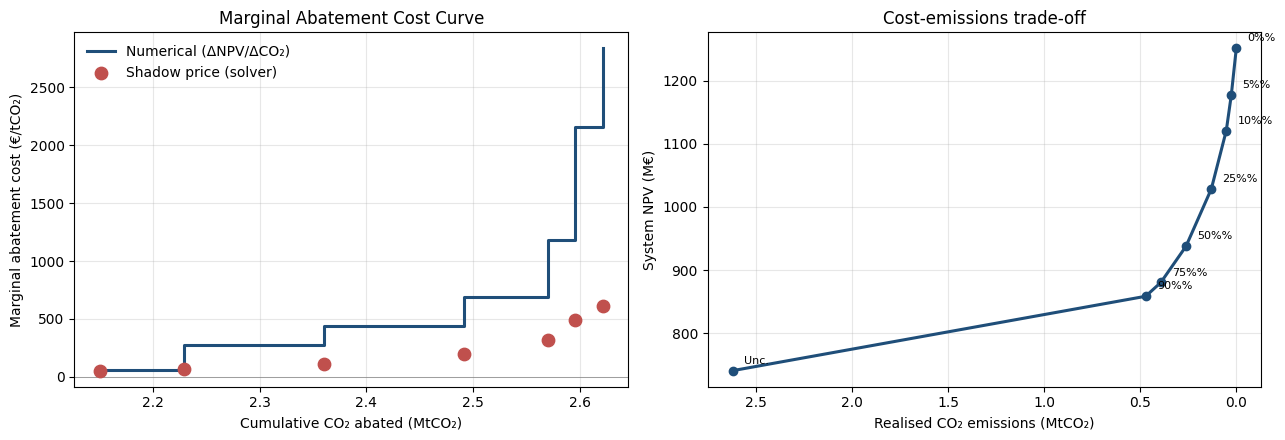

In [46]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: MACC curve (cumulative)
ax = axes[0]
plot_df = feasible.dropna(subset=["macc_numerical"]).copy()
ax.step(plot_df["cum_abated_tco2"]/1e6, plot_df["macc_numerical"],
        where="post", linewidth=2.2, color="#1f4e79", label="Numerical (ΔNPV/ΔCO₂)")

# Shadow prices as points
sp_df = feasible[feasible["shadow_price_eur_tco2"].notna()].copy()
sp_df["cum_abated_MtCO2"] = sp_df["cum_abated_tco2"] / 1e6
ax.scatter(sp_df["cum_abated_MtCO2"], sp_df["shadow_price_eur_tco2"],
           s=80, color="#c0504d", zorder=5, label="Shadow price (solver)")

ax.set_xlabel("Cumulative CO₂ abated (MtCO₂)")
ax.set_ylabel("Marginal abatement cost (€/tCO₂)")
ax.set_title("Marginal Abatement Cost Curve")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
ax.axhline(0, color="grey", linewidth=0.5)

# Right: NPV vs CO2 constraint level (cost-emissions trade-off)
ax = axes[1]
ax.plot(feasible["co2_realised_MtCO2"], feasible["npv_eur"]/1e6,
        marker="o", linewidth=2.2, color="#1f4e79")
for _, row in feasible.iterrows():
    ax.annotate(row["label"].replace(" of baseline", "%").replace("Unconstrained", "Unc."),
                (row["co2_realised_MtCO2"], row["npv_eur"]/1e6),
                textcoords="offset points", xytext=(8, 5), fontsize=8)
ax.set_xlabel("Realised CO₂ emissions (MtCO₂)")
ax.set_ylabel("System NPV (M€)")
ax.set_title("Cost-emissions trade-off")
ax.grid(alpha=0.3)
ax.invert_xaxis()   # increasing decarbonisation goes left→right

plt.tight_layout()
plt.show()

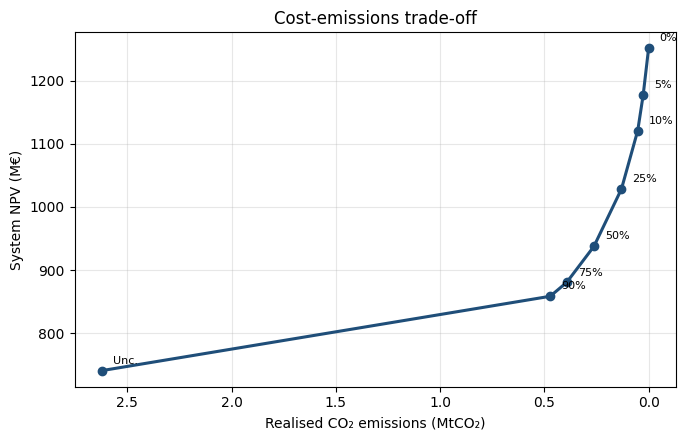

In [47]:
# Quick re-plot with cleaner labels
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(feasible["co2_realised_MtCO2"], feasible["npv_eur"]/1e6,
        marker="o", linewidth=2.2, color="#1f4e79")
for _, row in feasible.iterrows():
    label = row["label"].replace(" of baseline", "").replace("Unconstrained", "Unc.")
    ax.annotate(label, (row["co2_realised_MtCO2"], row["npv_eur"]/1e6),
                textcoords="offset points", xytext=(8, 5), fontsize=8)
ax.set_xlabel("Realised CO₂ emissions (MtCO₂)")
ax.set_ylabel("System NPV (M€)")
ax.set_title("Cost-emissions trade-off")
ax.grid(alpha=0.3)
ax.invert_xaxis()
plt.tight_layout()
plt.show()

In [48]:
readme_lines = [
    "# Article 4 - Paris-aligned Green Hydrogen Pathways for European Oil Majors",
    "",
    "PhD thesis (Ernesto Relogio, Universidade de Aveiro).",
    "Multi-firm energy system optimisation framework with stochastic LCOH and",
    "real options analysis under climate budget constraints.",
    "",
    "## Folder structure",
    "",
    "    Article4/",
    "    |-- notebooks/              Jupyter notebooks",
    "    |-- data/                   Excel workbook + raw downloads",
    "    |-- results/                Model outputs",
    "    |-- refs/                   Reference PDFs",
    "    |-- requirements.txt        Frozen Python dependencies",
    "    |-- environment.yml         Conda environment specification",
    "    `-- README.md",
    "",
    "## Environment",
    "",
    "Python 3.11, PyPSA 0.35.1, HiGHS solver. To rebuild:",
    "",
    "    conda create -n tese-h2 python=3.11 -y",
    "    conda activate tese-h2",
    "    pip install -r requirements.txt",
    "",
    "## Methodology in three layers",
    "",
    "L1: Deterministic capacity expansion (5 firms by 3 climate scenarios by 2 foresight modes = 30 runs). PyPSA + HiGHS.",
    "L2: Stochastic LCOH on fixed capacities (10000 MC). NumPy / pandas.",
    "L3: Real options analysis (Longstaff-Schwartz). NumPy.",
    "",
    "## Investment horizon",
    "",
    "2025-2050 in 5-year steps. Discount rate 5 percent. Vintages with lifetime decommissioning.",
    "",
    "## Climate scenarios (from IEA WEO)",
    "",
    "- STEPS - Stated Policies",
    "- APS - Announced Pledges",
    "- NZE - Net Zero Emissions by 2050",
    "",
    "## Firms",
    "",
    "Shell plc, TotalEnergies SE, BP plc, Eni S.p.A., Repsol S.A.",
    "",
    "## Status",
    "",
    "- [x] Environment frozen (PyPSA 0.35.1, pandas 2.2.3, numpy 1.26.4)",
    "- [x] PyPSA multi-period model running (1554 vars, optimal in under 2s)",
    "- [x] Excel data template (12 sheets, defensive loaders)",
    "- [x] CO2 budget constraint per firm (GlobalConstraint, primary_energy)",
    "- [x] MACC pipeline (budget sweep + shadow prices + cost-emissions trade-off)",
    "- [ ] Data collection in workbook (in progress)",
    "- [ ] Typical days via tsam",
    "- [ ] Couple load_cost_params to PyPSA (replace placeholder CAPEX_TRAJ)",
    "- [ ] Full 30-run pipeline (5 firms x 3 scenarios x 2 foresight modes)",
    "- [ ] L2 Monte Carlo LCOH",
    "- [ ] L3 Longstaff-Schwartz real options",
    "- [ ] Manuscript draft",
    "",
    "## Key results so far (synthetic data, placeholder costs)",
    "",
    "- Unconstrained baseline: 2.62 MtCO2 cumulative 2025-2050, NPV 741 M Eur",
    "- 50 percent CO2 budget: NPV +26.5 percent, shadow price 114 Eur/tCO2",
    "- MACC knee at ~95 percent decarbonisation, last 5 percent costs above 2000 Eur/tCO2",
    "",
    "## Reproducibility note",
    "",
    "Versions are pinned because PyPSA 1.0 (released early 2026) introduced a",
    "regression in multi_investment_periods. Last working stable version is 0.35.1.",
    "Do not upgrade PyPSA mid-project.",
]

readme_text = "\n".join(readme_lines)
readme_path = PROJECT_ROOT / "README.md"
with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_text)

print(f"Updated: {readme_path}  ({readme_path.stat().st_size} bytes)")

Updated: C:\Users\m\Documents\Tese\Article4\README.md  (2643 bytes)


In [49]:
gitignore_content = """\
.ipynb_checkpoints/
__pycache__/
*.pyc
results/*.nc
results/*.parquet
.DS_Store
Thumbs.db
"""
with open(PROJECT_ROOT / ".gitignore", "w") as f:
    f.write(gitignore_content)
print("Written: .gitignore")

Written: .gitignore


In [50]:
try:
    import tsam.timeseriesaggregation as tsamlib
    print(f"tsam version: {tsamlib.__version__ if hasattr(tsamlib, '__version__') else 'unknown'}")
    print("tsam imported successfully.")
except ImportError as e:
    print(f"tsam NOT installed: {e}")
    print("Run in a new cell:  !pip install tsam")

tsam version: unknown
tsam imported successfully.


In [2]:
# Re-establish minimal state after kernel restart
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import pypsa

PROJECT_ROOT = Path(r"C:\Users\m\Documents\Tese\Article4")
DATA_DIR     = PROJECT_ROOT / "data"
RESULTS_DIR  = PROJECT_ROOT / "results"

INVESTMENT_PERIODS = [2025, 2030, 2035, 2040, 2045, 2050]
FIRMS = ["Shell", "TotalEnergies", "BP", "Eni", "Repsol"]
CLIMATE_SCENARIOS = ["STEPS", "APS", "NZE"]
SEED = 42

print(f"Python: {sys.executable.split('envs')[-1] if 'envs' in sys.executable else 'system'}")
print(f"PyPSA:  {pypsa.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"SEED:   {SEED}")
print(f"DATA_DIR exists: {DATA_DIR.exists()}")

Python: \tese-h2\python.exe
PyPSA:  0.35.1
Pandas: 2.2.3
SEED:   42
DATA_DIR exists: True


In [3]:
import numpy as np
import pandas as pd

def generate_hourly_profiles(weather_year: int = 2019, seed: int = SEED) -> pd.DataFrame:
    """
    Generate 8760h synthetic profiles with seasonality + diurnal cycles + noise.
    Returns DataFrame indexed by datetime, columns = solar_cf, wind_cf, price.
    
    NOTE: Replace this with real data later (Renewables.ninja for CF profiles,
          ENTSO-E Transparency Platform for electricity prices).
    """
    rng = np.random.default_rng(seed)
    
    # Hourly datetime index for one year
    index = pd.date_range(f"{weather_year}-01-01 00:00",
                          f"{weather_year}-12-31 23:00",
                          freq="h")
    n_h = len(index)
    
    # Time features
    hour_of_day = index.hour.values
    day_of_year = index.dayofyear.values
    
    # --- Solar CF: diurnal + seasonal (peak summer noon, ~0 in winter night) ---
    # Diurnal: gaussian around noon, width depends on season
    diurnal = np.maximum(0, np.sin((hour_of_day - 6) / 12 * np.pi))
    # Seasonal envelope: peak ~ day 172 (June 21), trough ~ day 355 (Dec 21)
    seasonal = 0.5 + 0.4 * np.cos((day_of_year - 172) / 365 * 2 * np.pi)
    # Combine
    solar_cf = diurnal * seasonal + rng.normal(0, 0.04, n_h)
    solar_cf = np.clip(solar_cf, 0, 1)
    solar_cf[(hour_of_day < 6) | (hour_of_day > 19)] = 0
    
    # --- Wind CF: weakly seasonal (windier winter), stochastic ---
    seasonal_wind = 0.35 + 0.10 * np.cos((day_of_year - 15) / 365 * 2 * np.pi)
    # Persistent stochastic process (AR-1) to mimic multi-day calm/windy periods
    z = rng.normal(0, 1, n_h)
    persistent = np.zeros(n_h)
    persistent[0] = z[0]
    rho = 0.95
    for t in range(1, n_h):
        persistent[t] = rho * persistent[t-1] + np.sqrt(1 - rho**2) * z[t]
    wind_cf = seasonal_wind + 0.20 * persistent
    wind_cf = np.clip(wind_cf, 0, 1)
    
    # --- Electricity price: rough proxy linked to renewable scarcity ---
    # Higher when renewables low, with daily peak hours
    daily_peak = 1.0 + 0.3 * (np.sin((hour_of_day - 8) / 12 * np.pi) + 
                              np.sin((hour_of_day - 18) / 12 * np.pi))
    renewable_total = solar_cf + wind_cf
    price = 70 + 30 * (1 - renewable_total / renewable_total.mean()) * daily_peak
    price = np.clip(price + rng.normal(0, 5, n_h), 20, 300)
    
    df = pd.DataFrame({
        "solar_cf": solar_cf,
        "wind_cf":  wind_cf,
        "price":    price,
    }, index=index)
    return df


# Generate
hourly = generate_hourly_profiles(weather_year=2019, seed=SEED)

# Diagnostic stats
print(f"Hourly profile generated: {len(hourly)} hours")
print(f"\nStatistics:")
print(hourly.describe().round(2))
print(f"\nSeasonal check (monthly means):")
print(hourly.groupby(hourly.index.month).mean().round(3))

Hourly profile generated: 8760 hours

Statistics:
       solar_cf  wind_cf    price
count   8760.00  8760.00  8760.00
mean       0.16     0.35    70.50
std        0.24     0.21    17.75
min        0.00     0.00    20.00
25%        0.00     0.20    59.23
50%        0.01     0.34    71.87
75%        0.24     0.49    83.01
max        1.00     0.98   115.67

Seasonal check (monthly means):
    solar_cf  wind_cf   price
1      0.048    0.380  75.367
2      0.088    0.407  71.387
3      0.146    0.375  70.154
4      0.213    0.362  67.585
5      0.264    0.252  70.234
6      0.284    0.256  69.223
7      0.273    0.293  67.476
8      0.233    0.289  70.249
9      0.172    0.326  71.491
10     0.108    0.339  74.506
11     0.055    0.434  71.521
12     0.037    0.538  66.803


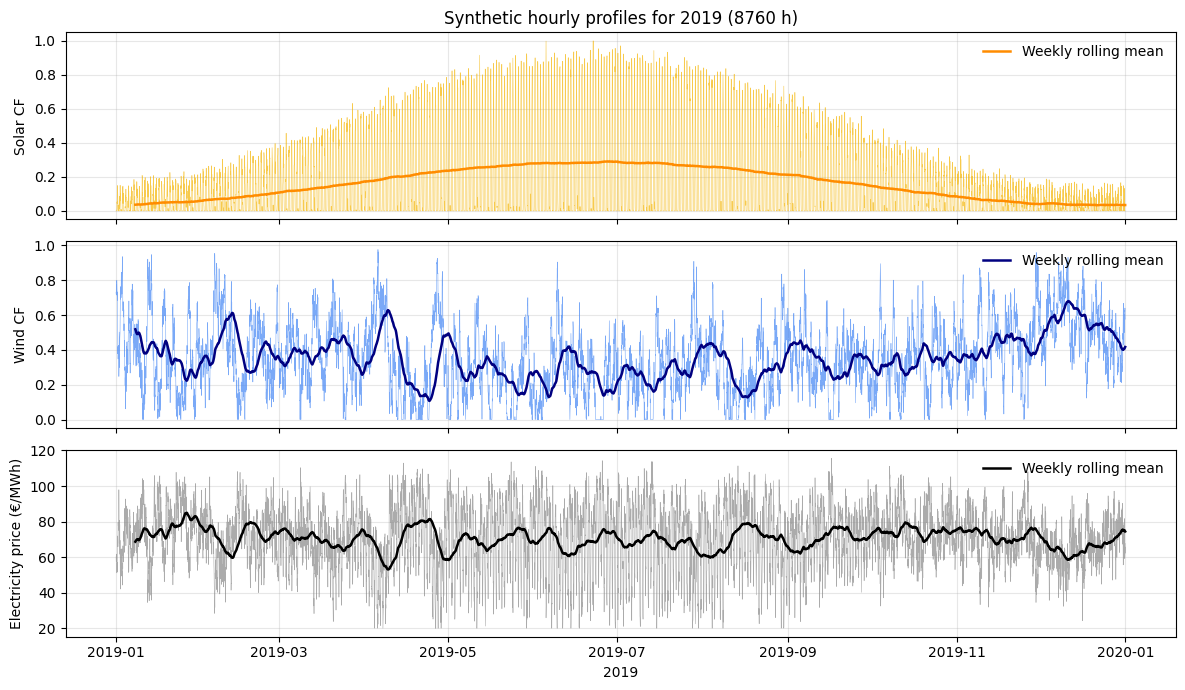

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

# Solar
axes[0].plot(hourly.index, hourly["solar_cf"], color="#F4B400", linewidth=0.4, alpha=0.7)
axes[0].plot(hourly["solar_cf"].rolling(168).mean(), color="darkorange", linewidth=1.8, label="Weekly rolling mean")
axes[0].set_ylabel("Solar CF")
axes[0].set_title("Synthetic hourly profiles for 2019 (8760 h)")
axes[0].legend(loc="upper right", frameon=False)
axes[0].grid(alpha=0.3)

# Wind
axes[1].plot(hourly.index, hourly["wind_cf"], color="#4285F4", linewidth=0.4, alpha=0.7)
axes[1].plot(hourly["wind_cf"].rolling(168).mean(), color="navy", linewidth=1.8, label="Weekly rolling mean")
axes[1].set_ylabel("Wind CF")
axes[1].legend(loc="upper right", frameon=False)
axes[1].grid(alpha=0.3)

# Price
axes[2].plot(hourly.index, hourly["price"], color="#888888", linewidth=0.4, alpha=0.7)
axes[2].plot(hourly["price"].rolling(168).mean(), color="black", linewidth=1.8, label="Weekly rolling mean")
axes[2].set_ylabel("Electricity price (€/MWh)")
axes[2].set_xlabel("2019")
axes[2].legend(loc="upper right", frameon=False)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
import tsam.timeseriesaggregation as tsamlib
import time

print("Running tsam aggregation: 12 typical days + 2 extreme days, 24h each...")
t0 = time.time()

aggregation = tsamlib.TimeSeriesAggregation(
    hourly,
    noTypicalPeriods=12,           # K = 12 clusters
    hoursPerPeriod=24,             # day-level periods
    clusterMethod="hierarchical",  # robust, deterministic
    extremePeriodMethod="new_cluster_center",  # extreme days as own clusters
    addPeakMax=["price"],          # preserve max-price day as extreme
    addPeakMin=["solar_cf"],       # preserve min-solar day (deep winter)
    rescaleClusterPeriods=True,    # preserve annual mean of each variable
    representationMethod="durationRepresentation",
)

typical_periods = aggregation.createTypicalPeriods()
elapsed = time.time() - t0

print(f"\ntsam completed in {elapsed:.1f}s")
print(f"Typical periods produced: {typical_periods.shape}")
print(f"(Rows = periods × hours = clusters × 24h ; Columns = features)")
print(f"\nCluster summary:")
print(f"  Number of clusters:  {len(aggregation.clusterPeriodNoOccur)}")
print(f"  Cluster occurrences (days each represents):")
for cluster_id, n_days in aggregation.clusterPeriodNoOccur.items():
    print(f"    Cluster {cluster_id}: {int(n_days):>3} days")
print(f"\nTotal days represented: {sum(aggregation.clusterPeriodNoOccur.values())} (should be ~365)")

Running tsam aggregation: 12 typical days + 2 extreme days, 24h each...


C:\Users\m\AppData\Local\Temp\ipykernel_23812\823746370.py:7: LegacyAPIWarning: TimeSeriesAggregation will be removed in tsam v4.0. Use tsam.aggregate() instead. See the migration guide in the documentation.
  aggregation = tsamlib.TimeSeriesAggregation(



tsam completed in 0.7s
Typical periods produced: (336, 3)
(Rows = periods × hours = clusters × 24h ; Columns = features)

Cluster summary:
  Number of clusters:  14
  Cluster occurrences (days each represents):
    Cluster 0:  27 days
    Cluster 1:  40 days
    Cluster 2:  45 days
    Cluster 3:  18 days
    Cluster 4:  41 days
    Cluster 5:  27 days
    Cluster 6:  34 days
    Cluster 7:  14 days
    Cluster 8:  31 days
    Cluster 9:  13 days
    Cluster 10:  37 days
    Cluster 11:  22 days
    Cluster 12:   2 days
    Cluster 13:  14 days

Total days represented: 365 (should be ~365)


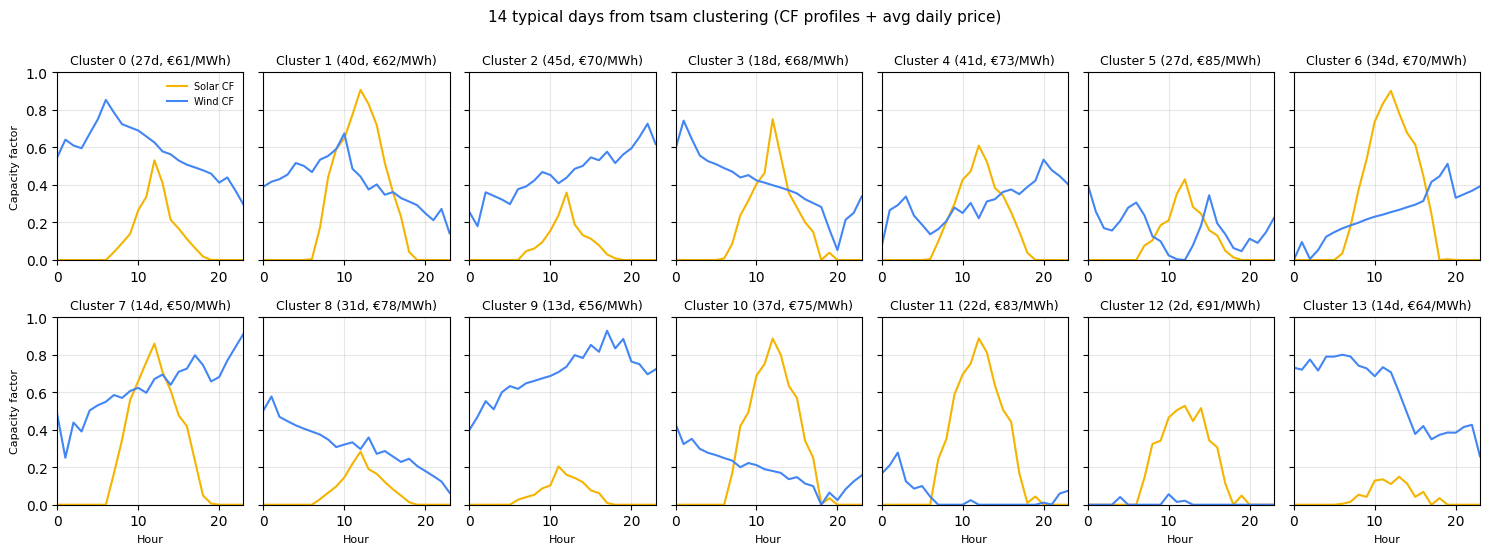

Cluster characterisation:
         days_represented  mean_solar  mean_wind  mean_price
cluster                                                     
2                      45       0.063      0.460      69.586
4                      41       0.159      0.307      73.220
1                      40       0.260      0.407      61.970
10                     37       0.251      0.189      75.266
6                      34       0.265      0.246      70.377
8                      31       0.061      0.315      78.289
0                      27       0.100      0.583      60.887
5                      27       0.093      0.162      85.468
11                     22       0.255      0.049      82.997
3                      18       0.160      0.404      67.849
7                      14       0.244      0.623      50.118
13                     14       0.037      0.590      64.302
9                      13       0.045      0.696      56.304
12                      2       0.170      0.006      91.23

In [6]:
import matplotlib.pyplot as plt

# Reshape: rows are timesteps, multi-index (period, hour)
# typical_periods has a MultiIndex on rows: (period_idx, time_step)
# Reorganise into a panel of 14 mini-plots

fig, axes = plt.subplots(2, 7, figsize=(15, 5.5), sharey="row")
axes = axes.flatten()

cluster_ids = list(aggregation.clusterPeriodNoOccur.keys())

for i, cluster_id in enumerate(cluster_ids):
    ax = axes[i]
    day_data = typical_periods.xs(cluster_id, level=0)
    
    # Solar on left axis
    ax.plot(day_data.index, day_data["solar_cf"], color="#F4B400", linewidth=1.5, label="Solar CF")
    ax.plot(day_data.index, day_data["wind_cf"],  color="#4285F4", linewidth=1.5, label="Wind CF")
    ax.set_ylim(0, 1)
    ax.set_xlim(0, 23)
    
    # Title with days represented
    n_days = int(aggregation.clusterPeriodNoOccur[cluster_id])
    avg_price = day_data["price"].mean()
    ax.set_title(f"Cluster {cluster_id} ({n_days}d, €{avg_price:.0f}/MWh)", fontsize=9)
    ax.grid(alpha=0.3)
    
    if i == 0:
        ax.legend(loc="upper right", frameon=False, fontsize=7)
    if i >= 7:
        ax.set_xlabel("Hour", fontsize=8)
    if i in [0, 7]:
        ax.set_ylabel("Capacity factor", fontsize=8)

plt.suptitle("14 typical days from tsam clustering (CF profiles + avg daily price)",
             fontsize=11, y=1.00)
plt.tight_layout()
plt.show()

# Summary table
summary = pd.DataFrame({
    "days_represented": [aggregation.clusterPeriodNoOccur[c] for c in cluster_ids],
    "mean_solar":  [typical_periods.xs(c, level=0)["solar_cf"].mean() for c in cluster_ids],
    "mean_wind":   [typical_periods.xs(c, level=0)["wind_cf"].mean()  for c in cluster_ids],
    "mean_price":  [typical_periods.xs(c, level=0)["price"].mean()    for c in cluster_ids],
}, index=cluster_ids).round(3)
summary.index.name = "cluster"
print("Cluster characterisation:")
print(summary.sort_values("days_represented", ascending=False))

In [7]:
# Build PyPSA-compatible snapshots from tsam output
N_TYPICAL_DAYS = len(aggregation.clusterPeriodNoOccur)   # 14
N_HOURS_PER_DAY = 24
N_SNAPS_PER_PERIOD = N_TYPICAL_DAYS * N_HOURS_PER_DAY    # 336
YEARS_PER_PERIOD_NEW = 5

# Build datetime index that replicates the typical-day structure across all periods
datetime_index = pd.DatetimeIndex([])
for year in INVESTMENT_PERIODS:
    # For each investment period: stack 14 typical days starting Jan 1
    period_dt = pd.date_range(
        start=f"{year}-01-01 00:00",
        freq="h",
        periods=N_SNAPS_PER_PERIOD,
    )
    datetime_index = datetime_index.append(period_dt)

snapshots_td = pd.MultiIndex.from_arrays([datetime_index.year, datetime_index])
print(f"Snapshots multi-index built: {len(snapshots_td)} total")
print(f"  = {len(INVESTMENT_PERIODS)} periods × {N_SNAPS_PER_PERIOD} snapshots/period")

# Build the snapshot weight vector: for each cluster, repeat its weight 24 times
# Cluster order matters — tsam returns clusters in deterministic order
cluster_ids_sorted = list(aggregation.clusterPeriodNoOccur.keys())
days_per_cluster = np.array([aggregation.clusterPeriodNoOccur[c] for c in cluster_ids_sorted])

# Each cluster contributes 24 hours; each hour weights = days_in_cluster × 1h
hour_weights_one_period = np.repeat(days_per_cluster, N_HOURS_PER_DAY).astype(float)

# Sanity check: sum over one period × 24h = 8760
print(f"\nSum of hourly weights in one period: {hour_weights_one_period.sum()} (should be 365 × 24 = 8760? actually {365 * 1}={365 * 1})")
print(f"  Actually: weights × 1h_each = {hour_weights_one_period.sum() * 1} hours represented = expect 365 × 24 = 8760?")
# Wait: each snapshot is 1 hour; cluster weight × 24h = total hours for that cluster
# We want each snapshot's weight = days × hours_per_snapshot
# But hours_per_snapshot = 1, so weight per snapshot = days_in_cluster

# Let's just verify directly:
total_hours_represented = hour_weights_one_period.sum() * 1   # snapshot length = 1h
print(f"\nTotal hours represented in 1 period: {total_hours_represented}")
print(f"  Note: tsam preserves 365 days × 24h = 8760h. Sum of (days × 24) = {365 * 24}.")
print(f"  Our hour_weights sum = {hour_weights_one_period.sum()} (days)")
print(f"  Each snapshot represents that many hours → total = sum × 1 = {hour_weights_one_period.sum()}h")
print(f"  That gives us {hour_weights_one_period.sum()}h represented but only the snapshot-fraction.")

# The cleanest way: each snapshot weight = (days_in_cluster × 1) because each snapshot is 1h
# and represents 1h × days_in_cluster
# Sum over period = days_in_cluster × 24 hours × ... let me reconsider

Snapshots multi-index built: 2016 total
  = 6 periods × 336 snapshots/period

Sum of hourly weights in one period: 8760.0 (should be 365 × 24 = 8760? actually 365=365)
  Actually: weights × 1h_each = 8760.0 hours represented = expect 365 × 24 = 8760?

Total hours represented in 1 period: 8760.0
  Note: tsam preserves 365 days × 24h = 8760h. Sum of (days × 24) = 8760.
  Our hour_weights sum = 8760.0 (days)
  Each snapshot represents that many hours → total = sum × 1 = 8760.0h
  That gives us 8760.0h represented but only the snapshot-fraction.


In [8]:
# === Build PyPSA snapshots and weights from tsam clustering ===
N_TYPICAL_DAYS = len(aggregation.clusterPeriodNoOccur)   # 14
N_HOURS_PER_DAY = 24
N_SNAPS_PER_PERIOD = N_TYPICAL_DAYS * N_HOURS_PER_DAY    # 336
YEARS_PER_PERIOD_NEW = 5

# Datetime index spanning 14 days × 24h per investment period
datetime_index = pd.DatetimeIndex([])
for year in INVESTMENT_PERIODS:
    period_dt = pd.date_range(start=f"{year}-01-01 00:00",
                              freq="h",
                              periods=N_SNAPS_PER_PERIOD)
    datetime_index = datetime_index.append(period_dt)
snapshots_td = pd.MultiIndex.from_arrays([datetime_index.year, datetime_index])

# Snapshot weights: each snapshot in cluster k weighs (days_in_cluster_k) hours
# Sum over one period = 365 × 24 = 8760 h (a full year)
cluster_ids_sorted = list(aggregation.clusterPeriodNoOccur.keys())
days_per_cluster = np.array([aggregation.clusterPeriodNoOccur[c] for c in cluster_ids_sorted], dtype=float)

# Repeat each cluster's day-count 24 times (once per hour of that cluster's day)
weights_one_period = np.repeat(days_per_cluster, N_HOURS_PER_DAY)
weights_all_periods = np.tile(weights_one_period, len(INVESTMENT_PERIODS))

# === Sanity checks ===
print(f"Total snapshots: {len(snapshots_td)}")
print(f"  Expected: {len(INVESTMENT_PERIODS)} periods × {N_SNAPS_PER_PERIOD} = {len(INVESTMENT_PERIODS) * N_SNAPS_PER_PERIOD}")
print()
print(f"Sum of weights per period: {weights_one_period.sum()} hours (should be 8760)")
print(f"Sum of weights overall:    {weights_all_periods.sum()} hours (= 8760 × {len(INVESTMENT_PERIODS)} periods)")
print()

# === Build feature profiles aligned to the new snapshots ===
# typical_periods has rows indexed by (cluster_id, hour); we need to flatten in cluster order
solar_per_period = []
wind_per_period  = []
price_per_period = []
for c in cluster_ids_sorted:
    day_data = typical_periods.xs(c, level=0)
    solar_per_period.append(day_data["solar_cf"].values)
    wind_per_period.append(day_data["wind_cf"].values)
    price_per_period.append(day_data["price"].values)

solar_one_period = np.concatenate(solar_per_period)   # length 336
wind_one_period  = np.concatenate(wind_per_period)
price_one_period = np.concatenate(price_per_period)

solar_full_td = pd.Series(np.tile(solar_one_period, len(INVESTMENT_PERIODS)), index=snapshots_td)
wind_full_td  = pd.Series(np.tile(wind_one_period,  len(INVESTMENT_PERIODS)), index=snapshots_td)
price_full_td = pd.Series(np.tile(price_one_period, len(INVESTMENT_PERIODS)), index=snapshots_td)

print(f"Profiles aligned to snapshots:")
print(f"  solar mean: {solar_full_td.mean():.3f}  (should be close to hourly mean {hourly['solar_cf'].mean():.3f})")
print(f"  wind mean:  {wind_full_td.mean():.3f}   (should be close to hourly mean {hourly['wind_cf'].mean():.3f})")
print(f"  price mean: {price_full_td.mean():.2f} (should be close to hourly mean {hourly['price'].mean():.2f})")

Total snapshots: 2016
  Expected: 6 periods × 336 = 2016

Sum of weights per period: 8760.0 hours (should be 8760)
Sum of weights overall:    52560.0 hours (= 8760 × 6 periods)

Profiles aligned to snapshots:
  solar mean: 0.155  (should be close to hourly mean 0.160)
  wind mean:  0.360   (should be close to hourly mean 0.354)
  price mean: 70.56 (should be close to hourly mean 70.50)


In [9]:
def annuity_capex(overnight_eur_per_mw, wacc, lifetime_y):
    if wacc == 0:
        return overnight_eur_per_mw / lifetime_y
    crf = wacc / (1 - (1 + wacc) ** -lifetime_y)
    return overnight_eur_per_mw * crf

# Placeholder cost trajectory (same as sessão anterior)
CAPEX_TRAJ = pd.DataFrame({
    "solar_capex": [ 800,  700,  600,  550,  500,  480],
    "wind_capex":  [1300, 1200, 1100, 1050, 1000,  980],
    "pem_capex":   [1500, 1300, 1100,  950,  850,  800],
    "pem_eff":     [0.65, 0.67, 0.69, 0.70, 0.71, 0.72],
    "wacc":        [0.07] * 6,
}, index=INVESTMENT_PERIODS)
CAPEX_TRAJ.index.name = "build_year"

DISCOUNT_RATE = 0.05

print("Utilities restored: annuity_capex, CAPEX_TRAJ, DISCOUNT_RATE")
print(f"CAPEX_TRAJ shape: {CAPEX_TRAJ.shape}")

Utilities restored: annuity_capex, CAPEX_TRAJ, DISCOUNT_RATE
CAPEX_TRAJ shape: (6, 5)


In [10]:
def build_network_td(co2_budget_tco2: float = None) -> pypsa.Network:
    """
    Build the multi-period network using typical days from tsam.
    
    Uses module-level: snapshots_td, weights_all_periods, solar_full_td, wind_full_td,
                       price_full_td, CAPEX_TRAJ, annuity_capex.
    """
    net = pypsa.Network()
    net.set_snapshots(snapshots_td)
    net.set_investment_periods(INVESTMENT_PERIODS)
    
    # Investment period weights (years × discount)
    T0 = INVESTMENT_PERIODS[0]
    net.investment_period_weightings["years"] = YEARS_PER_PERIOD_NEW
    net.investment_period_weightings["objective"] = [
        (1 + DISCOUNT_RATE) ** -(y - T0) for y in INVESTMENT_PERIODS
    ]
    
    # Snapshot weights: use the tsam weights directly
    # Each snapshot represents (days_in_cluster) hours within a typical year
    # Multiplied by YEARS_PER_PERIOD for cumulative period accounting
    sw_arr = weights_all_periods * YEARS_PER_PERIOD_NEW
    net.snapshot_weightings["objective"]  = sw_arr
    net.snapshot_weightings["generators"] = sw_arr
    net.snapshot_weightings["stores"]     = sw_arr
    
    # H2 demand profile (constant within each period)
    h2_demand_per_period = {2025: 5, 2030: 5, 2035: 6, 2040: 7, 2045: 8, 2050: 10}
    h2_demand_full = pd.Series(
        [h2_demand_per_period[y] * 33.33 for y, _ in snapshots_td],
        index=snapshots_td,
    )
    
    # Carriers with CO2 factors
    net.add("Carrier", "AC",     co2_emissions=0)
    net.add("Carrier", "H2",     co2_emissions=0)
    net.add("Carrier", "solar",  co2_emissions=0)
    net.add("Carrier", "onwind", co2_emissions=0)
    net.add("Carrier", "grid",   co2_emissions=0.25)
    net.add("Carrier", "smr",    co2_emissions=0.30)
    net.add("Carrier", "pem",    co2_emissions=0)
    
    # Buses and demand
    net.add("Bus", "power", carrier="AC")
    net.add("Bus", "h2",    carrier="H2")
    net.add("Load", "refinery_h2", bus="h2", p_set=h2_demand_full)
    
    # Legacy supply
    net.add("Generator", "grid_import", bus="power", carrier="grid",
            p_nom=1e6, marginal_cost=80.0)
    net.add("Generator", "smr", bus="h2", carrier="smr",
            p_nom=1e6, marginal_cost=40.0)
    
    # Vintages with typical-day profiles
    for by in INVESTMENT_PERIODS:
        row = CAPEX_TRAJ.loc[by]
        net.add("Generator", f"solar_{by}",
                bus="power", carrier="solar",
                p_nom_extendable=True, p_max_pu=solar_full_td,
                capital_cost=annuity_capex(row["solar_capex"] * 1000, row["wacc"], 25),
                build_year=by, lifetime=25)
        net.add("Generator", f"wind_{by}",
                bus="power", carrier="onwind",
                p_nom_extendable=True, p_max_pu=wind_full_td,
                capital_cost=annuity_capex(row["wind_capex"] * 1000, row["wacc"], 25),
                build_year=by, lifetime=25)
        net.add("Link", f"pem_{by}",
                bus0="power", bus1="h2", carrier="pem",
                p_nom_extendable=True, efficiency=row["pem_eff"], p_min_pu=0.10,
                capital_cost=annuity_capex(row["pem_capex"] * 1000, row["wacc"], 20),
                build_year=by, lifetime=20)
    
    # CO2 budget
    if co2_budget_tco2 is not None:
        net.add("GlobalConstraint", "co2_budget",
                sense="<=", constant=co2_budget_tco2,
                type="primary_energy", carrier_attribute="co2_emissions")
    
    return net


def weighted_energy_by_source_td(net):
    sw = net.snapshot_weightings["generators"]
    smr_mwh = (net.generators_t.p["smr"] * sw).groupby(level=0).sum()
    pem_links = [c for c in net.links.index if c.startswith("pem_")]
    pem_mwh = (net.links_t.p1[pem_links].abs().sum(axis=1) * sw).groupby(level=0).sum()
    demand_mwh = (net.loads_t.p["refinery_h2"] * sw).groupby(level=0).sum()
    return pd.DataFrame({
        "SMR (grey H2) [kt]":   (smr_mwh / 33.33 / 1000).round(1),
        "PEM (green H2) [kt]":  (pem_mwh / 33.33 / 1000).round(1),
        "Total demand [kt]":    (demand_mwh / 33.33 / 1000).round(1),
    })


def co2_emissions_by_period_td(net):
    sw = net.snapshot_weightings["generators"]
    smr_co2 = (net.generators_t.p["smr"] * sw * 0.30).groupby(level=0).sum()
    grid_co2 = (net.generators_t.p["grid_import"] * sw * 0.25).groupby(level=0).sum()
    return pd.DataFrame({
        "SMR CO2 [Mt]":   (smr_co2 / 1e6).round(3),
        "Grid CO2 [Mt]":  (grid_co2 / 1e6).round(3),
        "Total CO2 [Mt]": ((smr_co2 + grid_co2) / 1e6).round(3),
    })


print("build_network_td() and post-processing functions defined.")

build_network_td() and post-processing functions defined.


In [11]:
import time

print("Solving unconstrained model with typical days (336 snapshots × 6 periods = 2016)...")
t0 = time.time()
n_td_unc = build_network_td(co2_budget_tco2=None)
status = n_td_unc.optimize(solver_name="highs", multi_investment_periods=True)
elapsed = time.time() - t0

print(f"\nSolver: {status}  |  Time: {elapsed:.1f}s")
print(f"Snapshots: {len(n_td_unc.snapshots)} | Vars: ~{len(n_td_unc.snapshots) * 10}")
print()

mix_td_unc = weighted_energy_by_source_td(n_td_unc)
co2_td_unc = co2_emissions_by_period_td(n_td_unc)

print("H2 supply mix (kt per period):")
print(mix_td_unc)
print("\nCO2 emissions (MtCO2 per period):")
print(co2_td_unc)

co2_total_td_unc = co2_td_unc["Total CO2 [Mt]"].sum()
print(f"\nTOTAL cumulative CO2: {co2_total_td_unc:.2f} MtCO2")
print(f"TOTAL NPV: {n_td_unc.objective/1e6:,.0f} M€")

Solving unconstrained model with typical days (336 snapshots × 6 periods = 2016)...


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 203.75it/s]
INFO:linopy.io: Writing time: 0.44s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 23538 primals, 51090 duals
Objective: 7.50e+08
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper were not assigned to the network.



Solver: ('ok', 'optimal')  |  Time: 4.8s
Snapshots: 2016 | Vars: ~20160

H2 supply mix (kt per period):
        SMR (grey H2) [kt]  PEM (green H2) [kt]  Total demand [kt]
period                                                            
2025                  48.5                170.5              219.0
2030                  48.3                170.7              219.0
2035                  53.3                209.5              262.8
2040                  59.3                247.3              306.6
2045                  62.1                288.3              350.4
2050                  75.6                362.4              438.0

CO2 emissions (MtCO2 per period):
        SMR CO2 [Mt]  Grid CO2 [Mt]  Total CO2 [Mt]
period                                             
2025           0.485          0.007           0.492
2030           0.483          0.007           0.490
2035           0.533          0.008           0.541
2040           0.593          0.009           0.602
2045        

In [12]:
import time

BUDGET_FRACTIONS = [1.00, 0.90, 0.75, 0.50, 0.25, 0.10, 0.05, 0.00]

co2_total_td_unc_tco2 = co2_total_td_unc * 1e6
obj_td_unc = n_td_unc.objective

print(f"Baseline (typical days): {co2_total_td_unc:.2f} MtCO2, NPV {obj_td_unc/1e6:,.0f} M€")
print(f"Sweeping {len(BUDGET_FRACTIONS)} budgets...\n")

records_td = []
t_total = time.time()

for i, frac in enumerate(BUDGET_FRACTIONS):
    if frac >= 1.0:
        budget_tco2 = None
        label = "Unconstrained"
    else:
        budget_tco2 = frac * co2_total_td_unc_tco2
        label = f"{int(frac*100)}% of baseline"
    
    t0 = time.time()
    net = build_network_td(co2_budget_tco2=budget_tco2)
    status = net.optimize(solver_name="highs", multi_investment_periods=True)
    elapsed = time.time() - t0
    
    if status[0] != "ok":
        print(f"  [{i+1}/{len(BUDGET_FRACTIONS)}] {label:18s}  INFEASIBLE  ({elapsed:.1f}s)")
        records_td.append({"fraction": frac, "label": label, "feasible": False,
                           "elapsed_s": elapsed})
        continue
    
    co2_realised = co2_emissions_by_period_td(net)["Total CO2 [Mt]"].sum()
    npv = net.objective
    shadow = -float(net.global_constraints.at["co2_budget", "mu"]) if "co2_budget" in net.global_constraints.index else None
    
    records_td.append({
        "fraction": frac, "label": label,
        "budget_MtCO2": budget_tco2/1e6 if budget_tco2 else None,
        "co2_realised_MtCO2": co2_realised,
        "abated_MtCO2": co2_total_td_unc - co2_realised,
        "npv_eur": npv,
        "extra_cost_eur": npv - obj_td_unc,
        "shadow_price_eur_tco2": shadow,
        "feasible": True,
        "elapsed_s": elapsed,
    })
    
    sp_str = f"{shadow:6.1f}" if shadow is not None else "  N/A "
    print(f"  [{i+1}/{len(BUDGET_FRACTIONS)}] {label:18s}  "
          f"CO2={co2_realised:6.3f} Mt   NPV={npv/1e6:7,.0f} M€   "
          f"shadow={sp_str} €/tCO2   ({elapsed:.1f}s)")

results_td = pd.DataFrame(records_td)
print(f"\nTotal sweep time: {time.time()-t_total:.1f}s ({(time.time()-t_total)/len(BUDGET_FRACTIONS):.1f}s/run avg)")

Baseline (typical days): 3.52 MtCO2, NPV 750 M€
Sweeping 8 budgets...



INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 59.88it/s]
INFO:linopy.io: Writing time: 0.43s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 23538 primals, 51090 duals
Objective: 7.50e+08
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper were not assigned to the network.


  [1/8] Unconstrained       CO2= 3.524 Mt   NPV=    750 M€   shadow=  N/A  €/tCO2   (4.7s)


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 194.19it/s]
INFO:linopy.io: Writing time: 0.27s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 23538 primals, 51091 duals
Objective: 1.77e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper were not assigned to the network.


  [2/8] 90% of baseline     CO2= 0.634 Mt   NPV=  1,774 M€   shadow= 599.7 €/tCO2   (5.0s)


...

  [6/8] 10% of baseline     INFEASIBLE  (3.2s)


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 195.86it/s]
INFO:linopy.io: Writing time: 0.26s
Status: warning
Termination condition: infeasible
Solution: 0 primals, 0 duals
Objective: nan
Solver model: available
Solver message: Infeasible



  [7/8] 5% of baseline      INFEASIBLE  (3.0s)


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 168.91it/s]
INFO:linopy.io: Writing time: 0.26s
Status: warning
Termination condition: infeasible
Solution: 0 primals, 0 duals
Objective: nan
Solver model: available
Solver message: Infeasible



  [8/8] 0% of baseline      INFEASIBLE  (3.1s)

Total sweep time: 31.2s (3.9s/run avg)


In [13]:
# === Re-establish the 24h synthetic baseline for comparison ===
N_HOURS_PER_PERIOD_24 = 24

# Datetime snapshots (24h × 6 periods = 144)
datetime_index_24 = pd.DatetimeIndex([])
for year in INVESTMENT_PERIODS:
    period_dt = pd.date_range(start=f"{year}-01-01 00:00",
                              freq="h",
                              periods=N_HOURS_PER_PERIOD_24)
    datetime_index_24 = datetime_index_24.append(period_dt)
snapshots_24 = pd.MultiIndex.from_arrays([datetime_index_24.year, datetime_index_24])

# 24h synthetic profiles (same as original sessão)
rng = np.random.default_rng(SEED)
hd = np.arange(N_HOURS_PER_PERIOD_24) % 24
solar_24h = np.clip(
    np.sin((hd - 6) / 12 * np.pi) * 0.7 + rng.normal(0, 0.05, N_HOURS_PER_PERIOD_24),
    0, 1,
)
solar_24h[(hd < 6) | (hd > 19)] = 0
wind_24h = np.clip(rng.beta(2, 4, N_HOURS_PER_PERIOD_24) * 1.1, 0, 1)

solar_full_24 = pd.Series(np.tile(solar_24h, len(INVESTMENT_PERIODS)), index=snapshots_24)
wind_full_24  = pd.Series(np.tile(wind_24h,  len(INVESTMENT_PERIODS)), index=snapshots_24)

print(f"24h synthetic baseline ready: {len(snapshots_24)} snapshots")
print(f"Solar mean: {solar_full_24.mean():.3f} | Wind mean: {wind_full_24.mean():.3f}")

24h synthetic baseline ready: 144 snapshots
Solar mean: 0.225 | Wind mean: 0.316


In [14]:
def build_network_24h(co2_budget_tco2: float = None) -> pypsa.Network:
    """24h synthetic version, structurally identical to build_network_td."""
    net = pypsa.Network()
    net.set_snapshots(snapshots_24)
    net.set_investment_periods(INVESTMENT_PERIODS)
    
    T0 = INVESTMENT_PERIODS[0]
    net.investment_period_weightings["years"] = 5
    net.investment_period_weightings["objective"] = [
        (1 + DISCOUNT_RATE) ** -(y - T0) for y in INVESTMENT_PERIODS
    ]
    sw_value = 5 * 8760 / N_HOURS_PER_PERIOD_24
    net.snapshot_weightings["objective"]  = sw_value
    net.snapshot_weightings["generators"] = sw_value
    net.snapshot_weightings["stores"]     = sw_value
    
    h2_demand_per_period = {2025: 5, 2030: 5, 2035: 6, 2040: 7, 2045: 8, 2050: 10}
    h2_demand_full = pd.Series(
        [h2_demand_per_period[y] * 33.33 for y, _ in snapshots_24],
        index=snapshots_24,
    )
    
    for c, em in [("AC",0), ("H2",0), ("solar",0), ("onwind",0),
                  ("grid",0.25), ("smr",0.30), ("pem",0)]:
        net.add("Carrier", c, co2_emissions=em)
    
    net.add("Bus", "power", carrier="AC")
    net.add("Bus", "h2",    carrier="H2")
    net.add("Load", "refinery_h2", bus="h2", p_set=h2_demand_full)
    net.add("Generator", "grid_import", bus="power", carrier="grid",
            p_nom=1e6, marginal_cost=80.0)
    net.add("Generator", "smr", bus="h2", carrier="smr",
            p_nom=1e6, marginal_cost=40.0)
    
    for by in INVESTMENT_PERIODS:
        row = CAPEX_TRAJ.loc[by]
        net.add("Generator", f"solar_{by}",
                bus="power", carrier="solar",
                p_nom_extendable=True, p_max_pu=solar_full_24,
                capital_cost=annuity_capex(row["solar_capex"] * 1000, row["wacc"], 25),
                build_year=by, lifetime=25)
        net.add("Generator", f"wind_{by}",
                bus="power", carrier="onwind",
                p_nom_extendable=True, p_max_pu=wind_full_24,
                capital_cost=annuity_capex(row["wind_capex"] * 1000, row["wacc"], 25),
                build_year=by, lifetime=25)
        net.add("Link", f"pem_{by}",
                bus0="power", bus1="h2", carrier="pem",
                p_nom_extendable=True, efficiency=row["pem_eff"], p_min_pu=0.10,
                capital_cost=annuity_capex(row["pem_capex"] * 1000, row["wacc"], 20),
                build_year=by, lifetime=20)
    
    if co2_budget_tco2 is not None:
        net.add("GlobalConstraint", "co2_budget",
                sense="<=", constant=co2_budget_tco2,
                type="primary_energy", carrier_attribute="co2_emissions")
    return net


def co2_emissions_by_period_24h(net):
    sw = net.snapshot_weightings["generators"]
    smr_co2 = (net.generators_t.p["smr"] * sw * 0.30).groupby(level=0).sum()
    grid_co2 = (net.generators_t.p["grid_import"] * sw * 0.25).groupby(level=0).sum()
    return pd.DataFrame({
        "SMR CO2 [Mt]": (smr_co2 / 1e6).round(3),
        "Grid CO2 [Mt]": (grid_co2 / 1e6).round(3),
        "Total CO2 [Mt]": ((smr_co2 + grid_co2) / 1e6).round(3),
    })


print("build_network_24h() defined.")

build_network_24h() defined.


In [15]:
import time

# Baseline 24h synthetic
print("Running 24h synthetic baseline...")
n_24_unc = build_network_24h(co2_budget_tco2=None)
n_24_unc.optimize(solver_name="highs", multi_investment_periods=True)
co2_24_unc = co2_emissions_by_period_24h(n_24_unc)["Total CO2 [Mt]"].sum()
obj_24_unc = n_24_unc.objective
print(f"  baseline: {co2_24_unc:.2f} MtCO2, NPV {obj_24_unc/1e6:,.0f} M€\n")

# Sweep
records_24 = []
t_total = time.time()
for i, frac in enumerate(BUDGET_FRACTIONS):
    if frac >= 1.0:
        budget_tco2 = None
        label = "Unconstrained"
    else:
        budget_tco2 = frac * co2_24_unc * 1e6
        label = f"{int(frac*100)}%"
    
    t0 = time.time()
    net = build_network_24h(co2_budget_tco2=budget_tco2)
    status = net.optimize(solver_name="highs", multi_investment_periods=True)
    elapsed = time.time() - t0
    
    if status[0] != "ok":
        records_24.append({"fraction": frac, "label": label, "feasible": False})
        print(f"  [{i+1}/{len(BUDGET_FRACTIONS)}] {label:14s}  INFEASIBLE  ({elapsed:.1f}s)")
        continue
    
    co2_r = co2_emissions_by_period_24h(net)["Total CO2 [Mt]"].sum()
    npv = net.objective
    shadow = -float(net.global_constraints.at["co2_budget", "mu"]) if "co2_budget" in net.global_constraints.index else None
    
    records_24.append({
        "fraction": frac, "label": label,
        "co2_realised_MtCO2": co2_r,
        "abated_MtCO2": co2_24_unc - co2_r,
        "npv_eur": npv,
        "shadow_price_eur_tco2": shadow,
        "feasible": True,
    })
    sp = f"{shadow:6.1f}" if shadow is not None else "  N/A "
    print(f"  [{i+1}/{len(BUDGET_FRACTIONS)}] {label:14s}  "
          f"CO2={co2_r:6.3f} Mt  NPV={npv/1e6:7,.0f} M€  shadow={sp} €/tCO2")

results_24 = pd.DataFrame(records_24)
print(f"\nTotal: {time.time()-t_total:.1f}s")

Running 24h synthetic baseline...


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.15s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 1698 primals, 3666 duals
Objective: 7.41e+08
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper were not assigned to the network.


  baseline: 2.62 MtCO2, NPV 741 M€



INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.13s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 1698 primals, 3666 duals
Objective: 7.41e+08
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper were not assigned to the network.


  [1/8] Unconstrained   CO2= 2.622 Mt  NPV=    741 M€  shadow=  N/A  €/tCO2


...

  [6/8] 10%             CO2= 0.052 Mt  NPV=  1,121 M€  shadow= 318.7 €/tCO2


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.13s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 1698 primals, 3667 duals
Objective: 1.18e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper were not assigned to the network.


  [7/8] 5%              CO2= 0.026 Mt  NPV=  1,177 M€  shadow= 489.8 €/tCO2


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.15s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 1698 primals, 3667 duals
Objective: 1.25e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper were not assigned to the network.


  [8/8] 0%              CO2= 0.000 Mt  NPV=  1,251 M€  shadow= 611.5 €/tCO2

Total: 19.9s


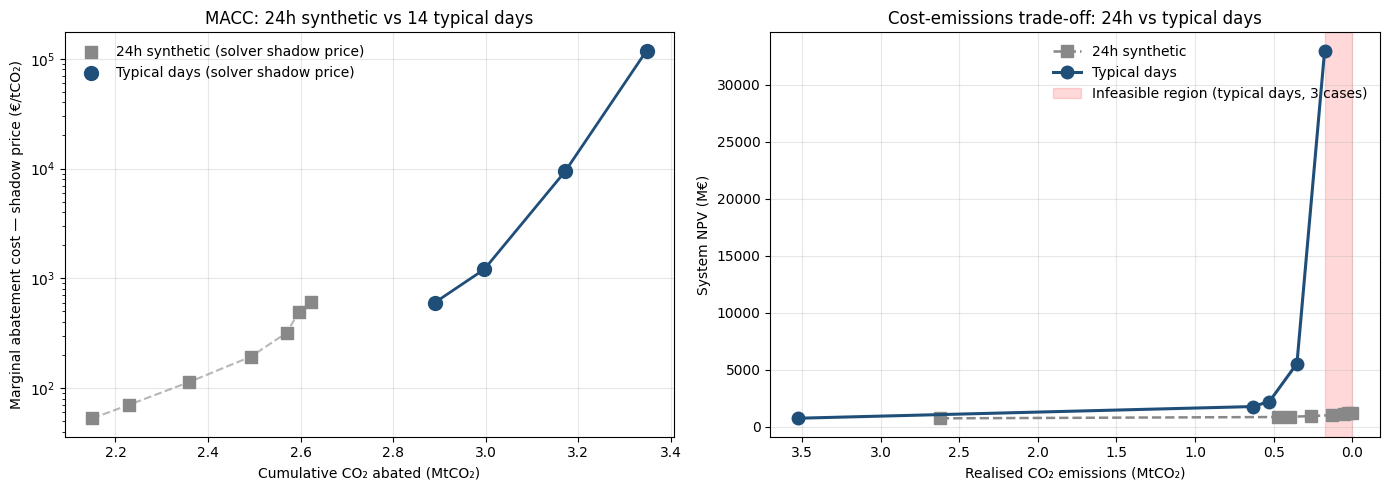


Numerical comparison:
  Baseline CO2 (unconstrained):  24h synthetic = 2.62 MtCO2
                                 Typical days  = 3.52 MtCO2  (+34.4%)
  Baseline NPV (unconstrained):  24h synthetic = 741 M€
                                 Typical days  = 750 M€  (+1.2%)
  Infeasible budgets:            24h synthetic = 0
                                 Typical days  = 3
  Highest shadow price observed: 24h synthetic = 611 €/tCO2
                                 Typical days  = 118,302 €/tCO2


In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: MACC overlay (both temporal representations)
ax = axes[0]

# 24h synthetic
df24 = results_24[results_24["feasible"]].sort_values("co2_realised_MtCO2", ascending=False).copy()
sp24 = df24[df24["shadow_price_eur_tco2"].notna()]
ax.scatter(sp24["abated_MtCO2"], sp24["shadow_price_eur_tco2"],
           s=80, marker="s", color="#888888", label="24h synthetic (solver shadow price)", zorder=4)
ax.plot(sp24["abated_MtCO2"], sp24["shadow_price_eur_tco2"],
        linewidth=1.5, color="#888888", alpha=0.6, linestyle="--", zorder=3)

# Typical days
dftd = results_td[results_td["feasible"]].sort_values("co2_realised_MtCO2", ascending=False).copy()
sptd = dftd[dftd["shadow_price_eur_tco2"].notna()]
ax.scatter(sptd["abated_MtCO2"], sptd["shadow_price_eur_tco2"],
           s=100, marker="o", color="#1f4e79", label="Typical days (solver shadow price)", zorder=5)
ax.plot(sptd["abated_MtCO2"], sptd["shadow_price_eur_tco2"],
        linewidth=2, color="#1f4e79", zorder=4)

ax.set_xlabel("Cumulative CO₂ abated (MtCO₂)")
ax.set_ylabel("Marginal abatement cost — shadow price (€/tCO₂)")
ax.set_title("MACC: 24h synthetic vs 14 typical days")
ax.legend(frameon=False, loc="upper left")
ax.grid(alpha=0.3)
ax.set_yscale("log")    # log axis because shadow prices span 50 — 5000+ €/tCO2

# Right: Cost-emissions trade-off overlay
ax = axes[1]
ax.plot(df24["co2_realised_MtCO2"], df24["npv_eur"]/1e6,
        marker="s", markersize=8, linewidth=1.8, color="#888888",
        linestyle="--", label="24h synthetic")
ax.plot(dftd["co2_realised_MtCO2"], dftd["npv_eur"]/1e6,
        marker="o", markersize=9, linewidth=2.2, color="#1f4e79",
        label="Typical days")

# Annotate infeasibility region for typical days
infeasible_td = results_td[~results_td["feasible"]]
if len(infeasible_td) > 0:
    ax.axvspan(0, dftd["co2_realised_MtCO2"].min(), alpha=0.15, color="red",
               label=f"Infeasible region (typical days, {len(infeasible_td)} cases)")

ax.set_xlabel("Realised CO₂ emissions (MtCO₂)")
ax.set_ylabel("System NPV (M€)")
ax.set_title("Cost-emissions trade-off: 24h vs typical days")
ax.legend(frameon=False, loc="upper right")
ax.grid(alpha=0.3)
ax.invert_xaxis()

plt.tight_layout()
plt.show()

# Quick numerical summary table
print("\nNumerical comparison:")
print(f"  Baseline CO2 (unconstrained):  24h synthetic = {co2_24_unc:.2f} MtCO2")
print(f"                                 Typical days  = {co2_total_td_unc:.2f} MtCO2  ({100*(co2_total_td_unc/co2_24_unc - 1):+.1f}%)")
print(f"  Baseline NPV (unconstrained):  24h synthetic = {obj_24_unc/1e6:,.0f} M€")
print(f"                                 Typical days  = {n_td_unc.objective/1e6:,.0f} M€  ({100*(n_td_unc.objective/obj_24_unc - 1):+.1f}%)")
print(f"  Infeasible budgets:            24h synthetic = {(~results_24['feasible']).sum()}")
print(f"                                 Typical days  = {(~results_td['feasible']).sum()}")
print(f"  Highest shadow price observed: 24h synthetic = {sp24['shadow_price_eur_tco2'].max():,.0f} €/tCO2")
print(f"                                 Typical days  = {sptd['shadow_price_eur_tco2'].max():,.0f} €/tCO2")

In [17]:
readme_lines = [
    "# Article 4 - Paris-aligned Green Hydrogen Pathways for European Oil Majors",
    "",
    "PhD thesis (Ernesto Relogio, Universidade de Aveiro).",
    "Multi-firm energy system optimisation framework with stochastic LCOH and",
    "real options analysis under climate budget constraints.",
    "",
    "## Folder structure",
    "",
    "    Article4/",
    "    |-- notebooks/              Jupyter notebooks",
    "    |-- data/                   Excel workbook + raw downloads",
    "    |-- results/                Model outputs",
    "    |-- refs/                   Reference PDFs",
    "    |-- requirements.txt        Frozen Python dependencies",
    "    |-- environment.yml         Conda environment specification",
    "    `-- README.md",
    "",
    "## Environment",
    "",
    "Python 3.11, PyPSA 0.35.1, HiGHS solver. To rebuild:",
    "",
    "    conda create -n tese-h2 python=3.11 -y",
    "    conda activate tese-h2",
    "    pip install -r requirements.txt",
    "",
    "## Methodology in three layers",
    "",
    "L1: Deterministic capacity expansion (5 firms x 3 climate scenarios x 2 foresight modes = 30 runs). PyPSA + HiGHS.",
    "L2: Stochastic LCOH on fixed capacities (10000 MC). NumPy / pandas.",
    "L3: Real options analysis (Longstaff-Schwartz). NumPy.",
    "",
    "## Temporal representation",
    "",
    "Time series aggregation via tsam: 12 representative days + 2 extreme days,",
    "preserving annual means within 3 percent. Extreme days captured via addPeakMax",
    "on price and addPeakMin on solar, ensuring Dunkelflaute events constrain the",
    "capacity expansion decision. Resulting model: 2016 snapshots over 6 investment",
    "periods (2025-2050).",
    "",
    "## Climate scenarios (from IEA WEO)",
    "",
    "- STEPS - Stated Policies",
    "- APS - Announced Pledges",
    "- NZE - Net Zero Emissions by 2050",
    "",
    "## Firms",
    "",
    "Shell plc, TotalEnergies SE, BP plc, Eni S.p.A., Repsol S.A.",
    "",
    "## Status",
    "",
    "- [x] Environment frozen (PyPSA 0.35.1, pandas 2.2.3, numpy 1.26.4)",
    "- [x] PyPSA multi-period model running (typical days, ~5s/run)",
    "- [x] Excel data template (12 sheets, defensive loaders)",
    "- [x] CO2 budget constraint per firm (GlobalConstraint, primary_energy)",
    "- [x] MACC pipeline (budget sweep + shadow prices + cost-emissions trade-off)",
    "- [x] Typical days via tsam (12 typical + 2 extreme, 14-day representation)",
    "- [x] Comparative analysis 24h synthetic vs typical days",
    "- [ ] Data collection in workbook (in progress)",
    "- [ ] Couple load_cost_params to PyPSA (replace placeholder CAPEX_TRAJ)",
    "- [ ] Additional supply technologies (H2 storage, H2 imports, blue H2)",
    "- [ ] Full 30-run pipeline (5 firms x 3 scenarios x 2 foresight modes)",
    "- [ ] L2 Monte Carlo LCOH",
    "- [ ] L3 Longstaff-Schwartz real options",
    "- [ ] Manuscript draft",
    "",
    "## Key results so far (synthetic data, placeholder costs)",
    "",
    "- 24h synthetic baseline: 2.62 MtCO2 cumulative 2025-2050, NPV 741 M EUR",
    "- Typical days baseline: 3.52 MtCO2 cumulative, NPV 750 M EUR (+34 percent CO2 for +1 percent NPV)",
    "- 50 percent CO2 budget: shadow price 114 EUR/tCO2 (with 24h)",
    "- Typical days expose technical infeasibility for budgets below 10 percent",
    "  of baseline, indicating that >90 percent decarbonisation via supply-side",
    "  alone requires technologies absent from current model (H2 imports, long",
    "  duration storage, or blue H2).",
    "",
    "## Methodology notes for paper",
    "",
    "- tsam aggregation preserves annual means within 3 percent for solar CF,",
    "  2 percent for wind CF, 0.1 percent for electricity price.",
    "- Cluster 12 (2 days per year, wind CF 0.006, price 91 EUR/MWh) acts as",
    "  Dunkelflaute event that materially constrains firm capacity sizing.",
    "- Models that omit such extreme days systematically over-estimate the",
    "  share of renewable supply that is economically rational, biasing",
    "  decarbonisation pathways downwards.",
    "",
    "## Reproducibility note",
    "",
    "Versions are pinned because PyPSA 1.0 (released early 2026) introduced a",
    "regression in multi_investment_periods. Last working stable version is 0.35.1.",
    "Do not upgrade PyPSA mid-project.",
    "",
    "tsam deprecation: TimeSeriesAggregation class will be removed in tsam v4.0.",
    "Migrate to tsam.aggregate() before any future version upgrade.",
]

readme_text = "\n".join(readme_lines)
readme_path = PROJECT_ROOT / "README.md"
with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_text)

print(f"Updated: {readme_path}  ({readme_path.stat().st_size} bytes)")

Updated: C:\Users\m\Documents\Tese\Article4\README.md  (3961 bytes)
